# VisionGuard AI — Image Preprocessing

This notebook prepares the five selected MVTec AD categories for TensorFlow and Keras based anomaly detection, CNN, autoencoder, reconstruction, and defect-localization workflows.

Selected categories:

**screw · bottle · capsule · metal_nut · hazelnut**

The notebook uses a local VisionGuard-AI project structure, clean notebook output, TensorFlow/Keras preprocessing, `tf.data` pipelines, ground-truth masks, augmentation previews, and saved preprocessing artifacts.


# Install Dependencies

Install the TensorFlow and EDA stack into the active notebook environment.


In [1]:
import sys
import subprocess
import warnings
import os

packages = [
    "tensorflow",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "pillow",
    "tqdm",
    "scipy",
    "scikit-learn",
    "plotly",
    "kaleido",
    "nbformat",
    "ipython"
]

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "-U", *packages],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

print("TensorFlow preprocessing environment ready.")


TensorFlow preprocessing environment ready.


# Import Libraries


In [2]:
import os
import random
import shutil
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from PIL import Image, ImageFile
from scipy import ndimage
from sklearn.model_selection import train_test_split

import tensorflow as tf

from IPython.display import display, Image as IPyImage

ImageFile.LOAD_TRUNCATED_IMAGES = True

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 17
plt.rcParams["axes.labelsize"] = 12

print("Libraries loaded.")
print(f"TensorFlow {tf.__version__}")


Libraries loaded.
TensorFlow 2.22.0-rc0


# Project Configuration

Configure the local VisionGuard-AI directories.


In [3]:
def detect_project_root():
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]

    for folder in candidates:
        markers = [
            (folder / ".git").exists(),
            (folder / "README.md").exists(),
            (folder / "notebooks").is_dir(),
            (folder / "src").is_dir()
        ]
        if sum(markers) >= 2:
            return folder

    return current

PROJECT_ROOT = detect_project_root()

CATEGORIES = [
    "screw",
    "bottle",
    "capsule",
    "metal_nut",
    "hazelnut"
]

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}

RAW_ROOT = PROJECT_ROOT / "data" / "raw" / "mvtec_5_categories"
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"
SAMPLES_ROOT = PROJECT_ROOT / "data" / "samples"
GRAPHS_ROOT = PROJECT_ROOT / "outputs" / "graphs"

TRAIN_ROOT = PROCESSED_ROOT / "train"
VALIDATION_ROOT = PROCESSED_ROOT / "validation"
TEST_ROOT = PROCESSED_ROOT / "test"
MASK_ROOT = PROCESSED_ROOT / "masks"

for folder in [
    PROCESSED_ROOT,
    SAMPLES_ROOT,
    GRAPHS_ROOT,
    TRAIN_ROOT,
    VALIDATION_ROOT,
    TEST_ROOT,
    MASK_ROOT
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project configuration ready.")


Project configuration ready.


# Preprocessing Configuration

Define the common image resolution, split ratio, normalization, and batch settings.


In [4]:
IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)

VALIDATION_FRACTION = 0.20
BATCH_SIZE = 32
PREFETCH_BUFFER = tf.data.AUTOTUNE

NORMALIZATION_LAYER = tf.keras.layers.Rescaling(
    1.0 / 255.0
)

print(f"Target resolution: {IMAGE_HEIGHT} × {IMAGE_WIDTH}")
print(f"Validation fraction: {VALIDATION_FRACTION:.0%}")
print(f"Batch size: {BATCH_SIZE}")
print("Normalization: 0–1 RGB scaling")


Target resolution: 256 × 256
Validation fraction: 20%
Batch size: 32
Normalization: 0–1 RGB scaling


# Utility Functions


In [5]:
def get_image_files(folder):
    folder = Path(folder)
    if not folder.exists():
        return []
    return sorted([
        file_path
        for file_path in folder.rglob("*")
        if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS
    ])

def count_images(folder):
    return len(get_image_files(folder))

def load_rgb(image_path):
    return Image.open(image_path).convert("RGB")

def load_gray(image_path):
    return Image.open(image_path).convert("L")

def resize_rgb(image):
    return image.resize(
        IMAGE_SIZE,
        Image.Resampling.BILINEAR
    )

def resize_mask(mask):
    return mask.resize(
        IMAGE_SIZE,
        Image.Resampling.NEAREST
    )

def save_static_figure(filename):
    output = GRAPHS_ROOT / filename
    plt.savefig(
        output,
        dpi=200,
        bbox_inches="tight",
        facecolor="white"
    )

def export_plotly(fig, filename, width=1400, height=800):
    html_output = GRAPHS_ROOT / f"{filename}.html"
    png_output = GRAPHS_ROOT / f"{filename}.png"

    fig.write_html(
        str(html_output),
        include_plotlyjs="cdn"
    )

    try:
        fig.write_image(
            str(png_output),
            width=width,
            height=height,
            scale=2
        )
    except Exception:
        pass

def show_saved_figure(filename):
    image_path = GRAPHS_ROOT / filename
    if image_path.exists():
        display(IPyImage(filename=str(image_path)))

print("Utility functions ready.")


Utility functions ready.


# Validate Raw Dataset

Confirm the selected categories and expected folder structure.


In [6]:
availability = []

for category in CATEGORIES:
    category_dir = RAW_ROOT / category

    availability.append({
        "Category": category,
        "Available": category_dir.is_dir(),
        "Train": (category_dir / "train").is_dir(),
        "Test": (category_dir / "test").is_dir(),
        "Ground Truth": (category_dir / "ground_truth").is_dir()
    })

availability_df = pd.DataFrame(availability)

display(
    availability_df.style
    .hide(axis="index")
    .background_gradient(
        cmap="GnBu"
    )
)

if not availability_df[
    ["Available", "Train", "Test", "Ground Truth"]
].all().all():
    raise RuntimeError(
        "The raw MVTec dataset structure is incomplete."
    )

print("Raw dataset validation passed.")


Category,Available,Train,Test,Ground Truth
screw,True,True,True,True
bottle,True,True,True,True
capsule,True,True,True,True
metal_nut,True,True,True,True
hazelnut,True,True,True,True


Raw dataset validation passed.


# Build Training Manifest

Create the normal-image training manifest used by the TensorFlow pipeline.


In [7]:
train_records = []

for category in CATEGORIES:
    for image_path in get_image_files(RAW_ROOT / category / "train"):
        train_records.append({
            "Category": category,
            "Split": "train",
            "Anomaly Label": 0,
            "Defect Type": "good",
            "Filename": image_path.name,
            "Image Path": str(image_path)
        })

train_df = pd.DataFrame(train_records)

print(f"Training images: {len(train_df):,}")
display(train_df.head(10))


Training images: 1,359


,Category,Split,Anomaly Label,Defect Type,Filename,Image Path
0,screw,train,0,good,000.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
1,screw,train,0,good,001.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
2,screw,train,0,good,002.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
3,screw,train,0,good,003.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
4,screw,train,0,good,004.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
5,screw,train,0,good,005.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
6,screw,train,0,good,006.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
7,screw,train,0,good,007.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
8,screw,train,0,good,008.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
9,screw,train,0,good,009.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...


# Create Train and Validation Splits

Split normal training images by category.


In [8]:
train_parts = []
validation_parts = []

for category in CATEGORIES:
    category_df = train_df[
        train_df["Category"] == category
    ].copy()

    train_part, validation_part = train_test_split(
        category_df,
        test_size=VALIDATION_FRACTION,
        random_state=42,
        shuffle=True
    )

    train_part["Split"] = "train"
    validation_part["Split"] = "validation"

    train_parts.append(train_part)
    validation_parts.append(validation_part)

train_split_df = pd.concat(
    train_parts,
    ignore_index=True
)

validation_df = pd.concat(
    validation_parts,
    ignore_index=True
)

split_summary = pd.DataFrame({
    "Category": CATEGORIES,
    "Train": [
        len(train_split_df[train_split_df["Category"] == category])
        for category in CATEGORIES
    ],
    "Validation": [
        len(validation_df[validation_df["Category"] == category])
        for category in CATEGORIES
    ]
})

display(split_summary)


,Category,Train,Validation
0,screw,256,64
1,bottle,167,42
2,capsule,175,44
3,metal_nut,176,44
4,hazelnut,312,79


# Build Test Manifest

Create a labeled test manifest containing normal and defective samples.


In [9]:
test_records = []

for category in CATEGORIES:
    test_dir = RAW_ROOT / category / "test"

    for defect_dir in sorted(test_dir.iterdir()):
        if not defect_dir.is_dir():
            continue

        defect_type = defect_dir.name
        anomaly_label = 0 if defect_type.lower() == "good" else 1

        for image_path in get_image_files(defect_dir):
            test_records.append({
                "Category": category,
                "Split": "test",
                "Anomaly Label": anomaly_label,
                "Defect Type": defect_type,
                "Filename": image_path.name,
                "Image Path": str(image_path)
            })

test_df = pd.DataFrame(test_records)

print(f"Test images: {len(test_df):,}")
display(test_df.head(12))


Test images: 600


,Category,Split,Anomaly Label,Defect Type,Filename,Image Path
0,screw,test,0,good,000.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
1,screw,test,0,good,001.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
2,screw,test,0,good,002.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
3,screw,test,0,good,003.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
4,screw,test,0,good,004.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
5,screw,test,0,good,005.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
6,screw,test,0,good,006.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
7,screw,test,0,good,007.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
8,screw,test,0,good,008.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...
9,screw,test,0,good,009.png,C:\Users\as178\OneDrive\Documents\ROADMAP\Seme...


# Train Validation Distribution


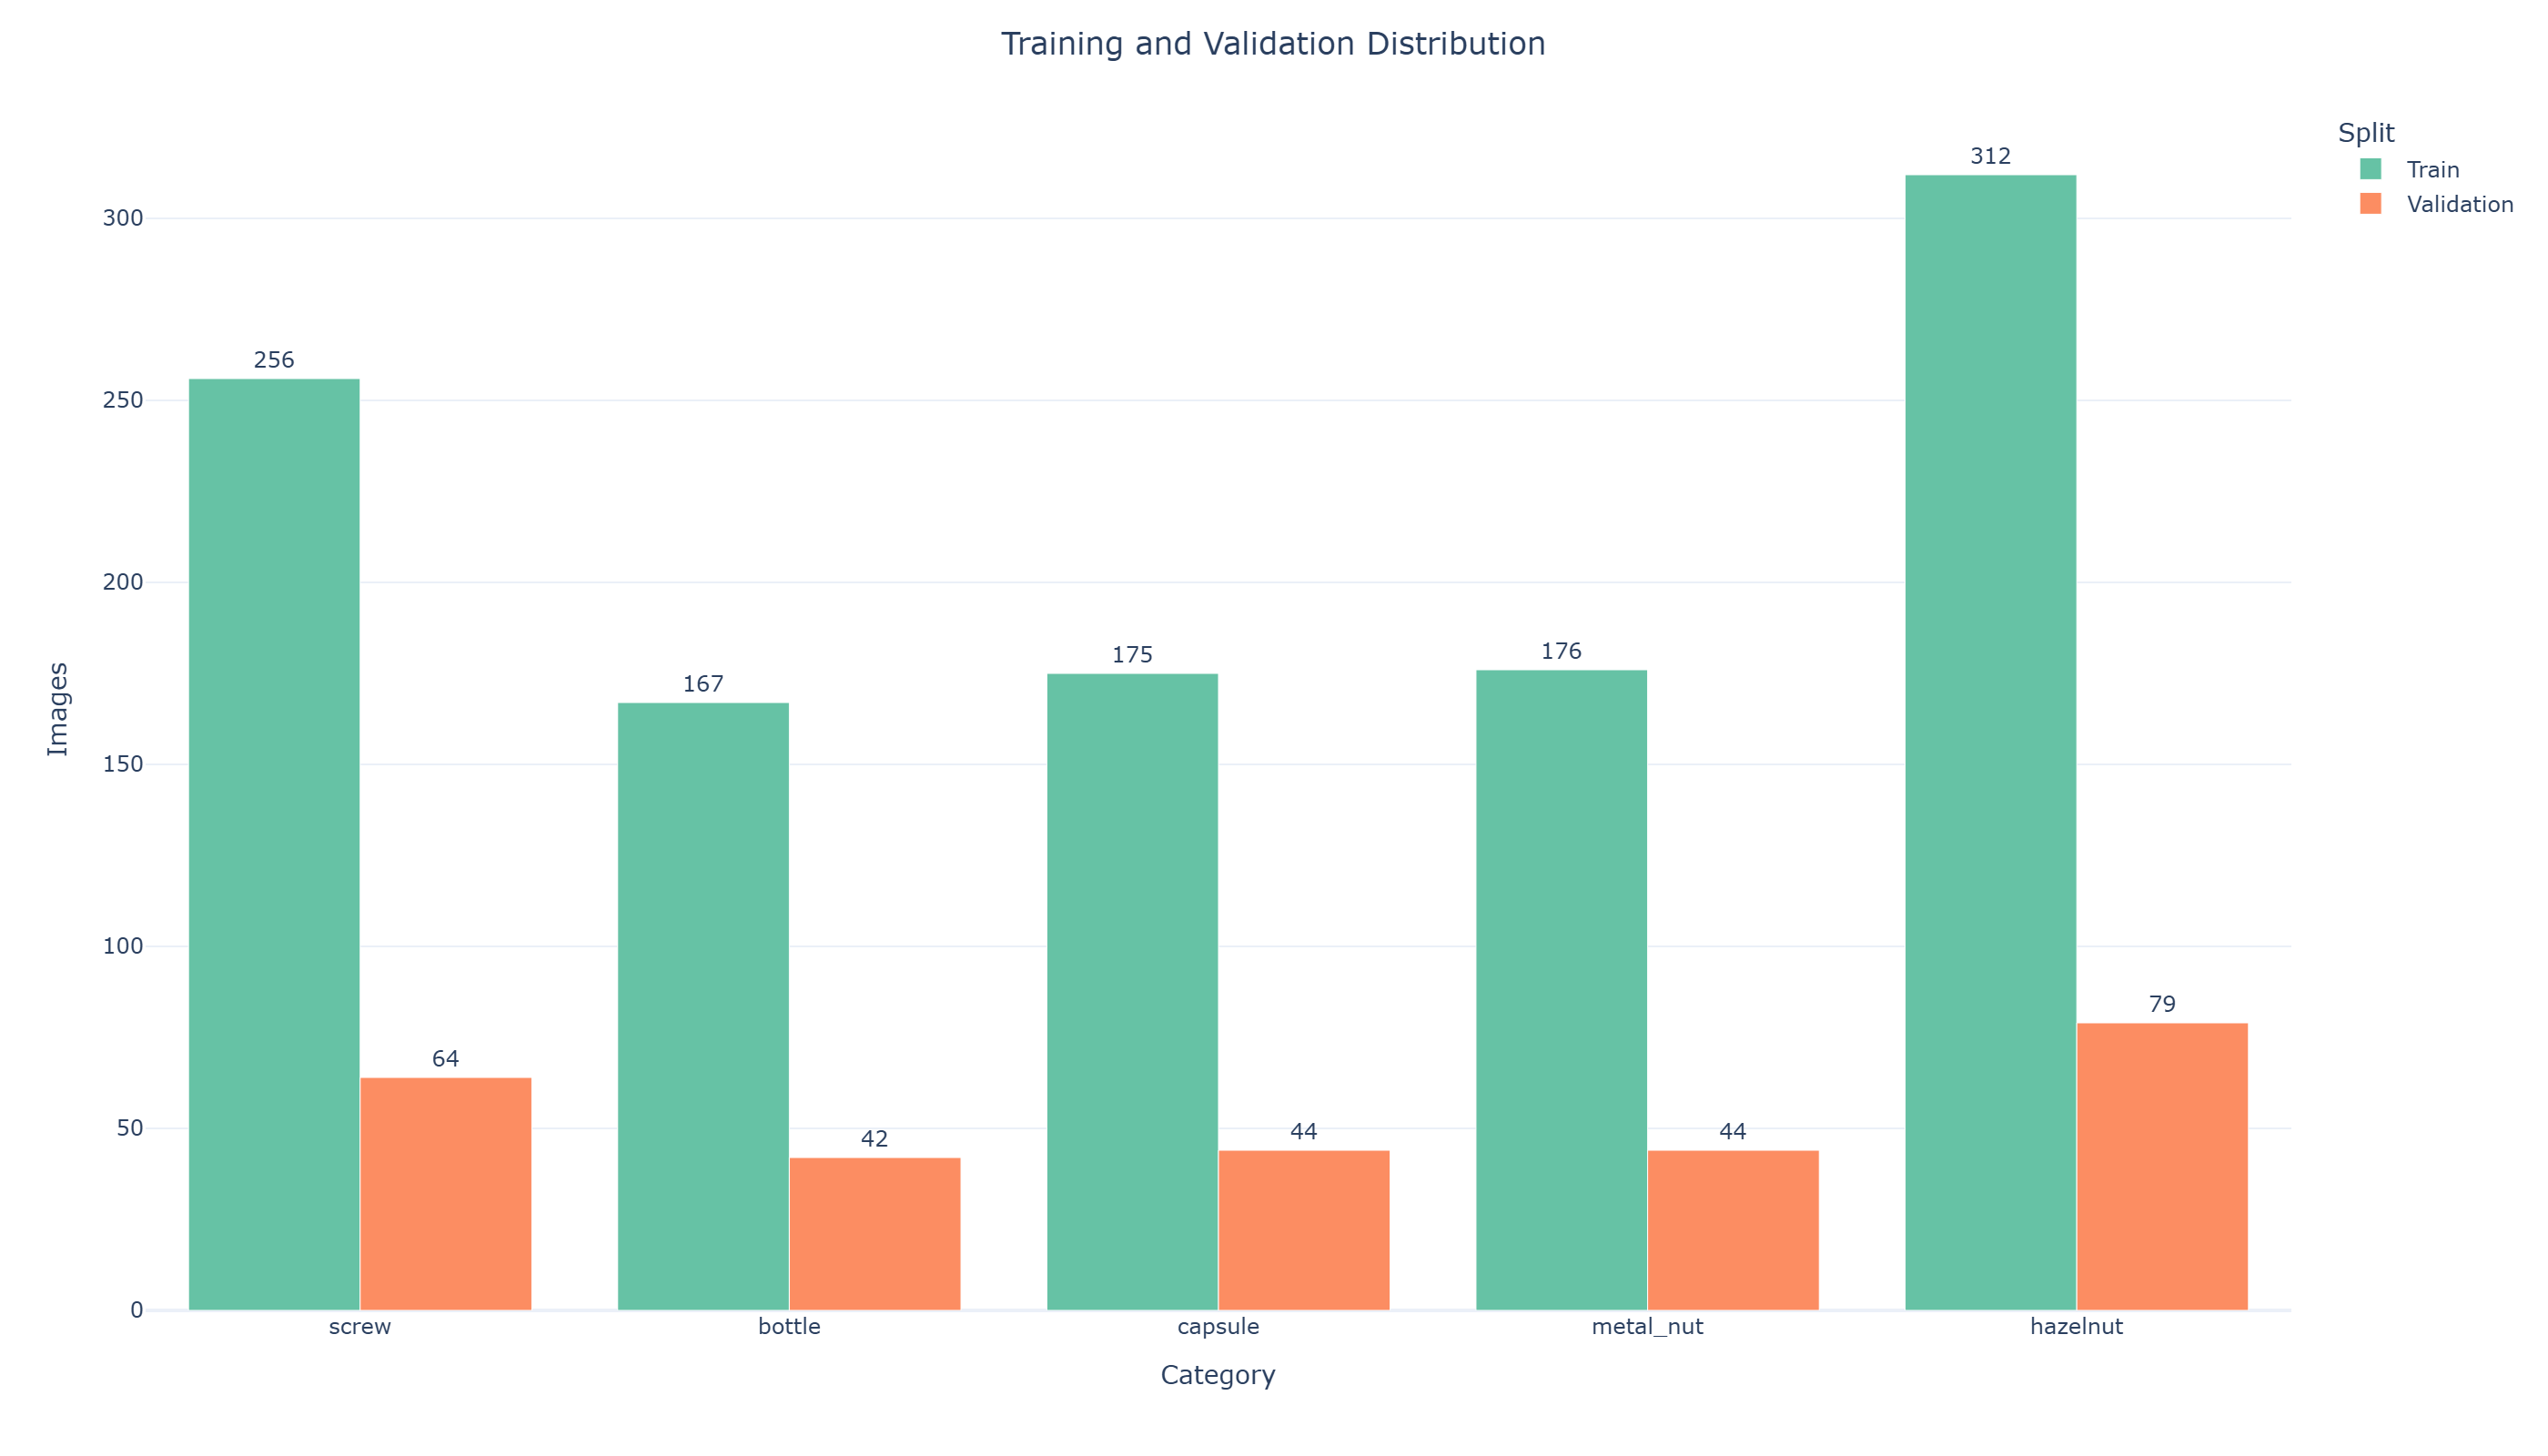

In [10]:
plot_df = split_summary.melt(
    id_vars="Category",
    var_name="Split",
    value_name="Images"
)

fig = px.bar(
    plot_df,
    x="Category",
    y="Images",
    color="Split",
    barmode="group",
    text="Images",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(textposition="outside")

fig.update_layout(
    title={"text": "Training and Validation Distribution", "x": 0.5},
    template="plotly_white",
    xaxis_title="Category",
    yaxis_title="Images",
    width=1200,
    height=700
)

export_plotly(fig, "tf_train_validation_distribution")
show_saved_figure("tf_train_validation_distribution.png")


# TensorFlow Augmentation Pipeline

Create the Keras augmentation pipeline used for normal training images.


In [11]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=42),
    tf.keras.layers.RandomRotation(0.03, seed=42),
    tf.keras.layers.RandomContrast(0.15, seed=42),
    tf.keras.layers.RandomBrightness(0.10, seed=42)
])

print("TensorFlow augmentation pipeline created.")


TensorFlow augmentation pipeline created.


# TensorFlow Dataset Loader

Create `tf.data` loaders with resizing, normalization, batching, and prefetching.


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

def decode_resize_normalize(path):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(
        image,
        [IMAGE_HEIGHT, IMAGE_WIDTH],
        method=tf.image.ResizeMethod.BILINEAR
    )
    image = tf.cast(image, tf.float32) / 255.0
    return image

def build_tf_dataset(paths, training=False):
    path_tensor = tf.constant(
        paths,
        dtype=tf.string
    )

    dataset = tf.data.Dataset.from_tensor_slices(
        path_tensor
    )

    dataset = dataset.map(
        decode_resize_normalize,
        num_parallel_calls=AUTOTUNE
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=max(len(paths), BATCH_SIZE * 4),
            seed=42,
            reshuffle_each_iteration=True
        )
        dataset = dataset.map(
            augmentation,
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(PREFETCH_BUFFER)

    return dataset

train_paths = train_split_df["Image Path"].tolist()
validation_paths = validation_df["Image Path"].tolist()

train_dataset = build_tf_dataset(
    train_paths,
    training=True
)

validation_dataset = build_tf_dataset(
    validation_paths,
    training=False
)

print("TensorFlow datasets created.")


TensorFlow datasets created.


# TensorFlow Batch Inspection

Verify tensor shapes and normalized ranges.


In [13]:
sample_batch = next(iter(train_dataset))

print("Batch shape:", tuple(sample_batch.shape))
print("Data type:", sample_batch.dtype)
print("Minimum:", float(tf.reduce_min(sample_batch)))
print("Maximum:", float(tf.reduce_max(sample_batch)))
print("Mean:", float(tf.reduce_mean(sample_batch)))
print("Std:", float(tf.math.reduce_std(sample_batch)))


Batch shape: (32, 256, 256, 3)
Data type: <dtype: 'float32'>
Minimum: 0.0
Maximum: 24.66449546813965
Mean: 7.063077926635742
Std: 8.940113067626953


# Augmentation Preview

Visualize multiple TensorFlow augmentation results.


In [14]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),
    tf.keras.layers.RandomRotation(
        0.08
    ),
    tf.keras.layers.RandomContrast(
        0.10
    ),
    tf.keras.layers.RandomBrightness(
        factor=0.10,
        value_range=(0, 1)
    )
])

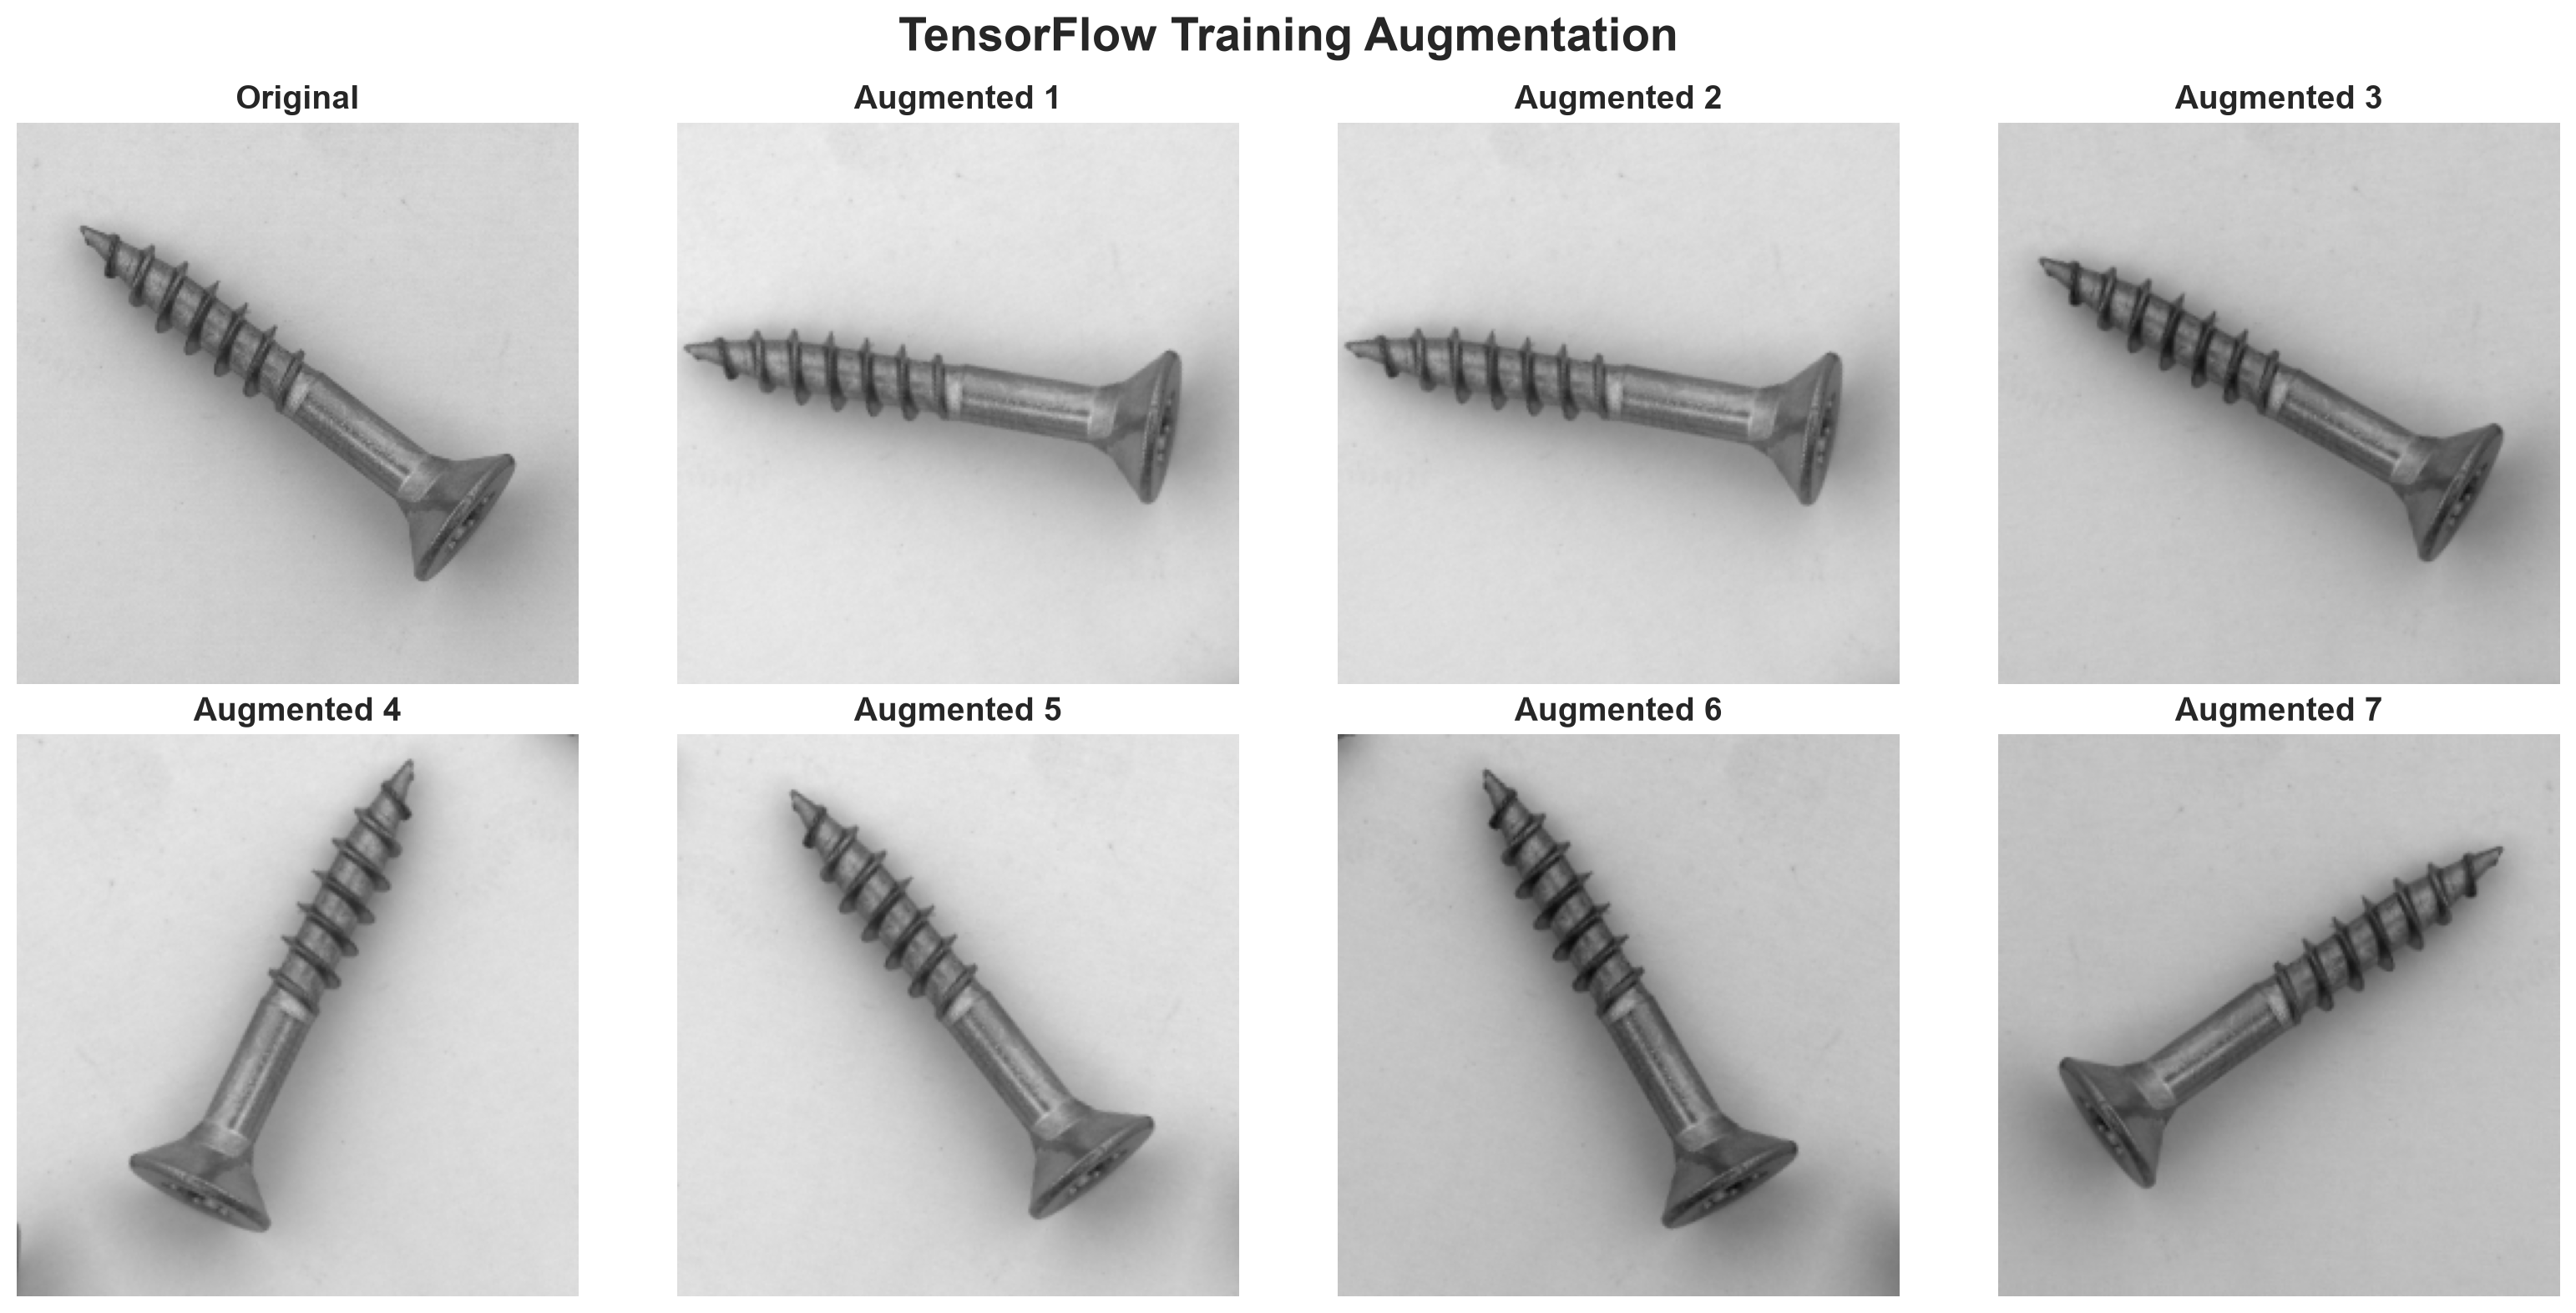

In [15]:
sample_path = train_split_df.iloc[0]["Image Path"]

sample_image = decode_resize_normalize(
    tf.constant(sample_path)
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

axes[0, 0].imshow(
    tf.clip_by_value(
        sample_image,
        0.0,
        1.0
    ).numpy()
)

axes[0, 0].set_title(
    "Original",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].axis("off")

for index in range(1, 8):

    augmented_image = augmentation(
        sample_image,
        training=True
    )

    augmented_image = tf.clip_by_value(
        augmented_image,
        0.0,
        1.0
    )

    axes.flat[index].imshow(
        augmented_image.numpy()
    )

    axes.flat[index].set_title(
        f"Augmented {index}",
        fontsize=14,
        fontweight="bold"
    )

    axes.flat[index].axis("off")

plt.suptitle(
    "TensorFlow Training Augmentation",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

save_static_figure(
    "tensorflow_augmentation_preview.png"
)

show_saved_figure(
    "tensorflow_augmentation_preview.png"
)

plt.close()

# Normalization Preview

Compare RGB values before and after 0–1 scaling.


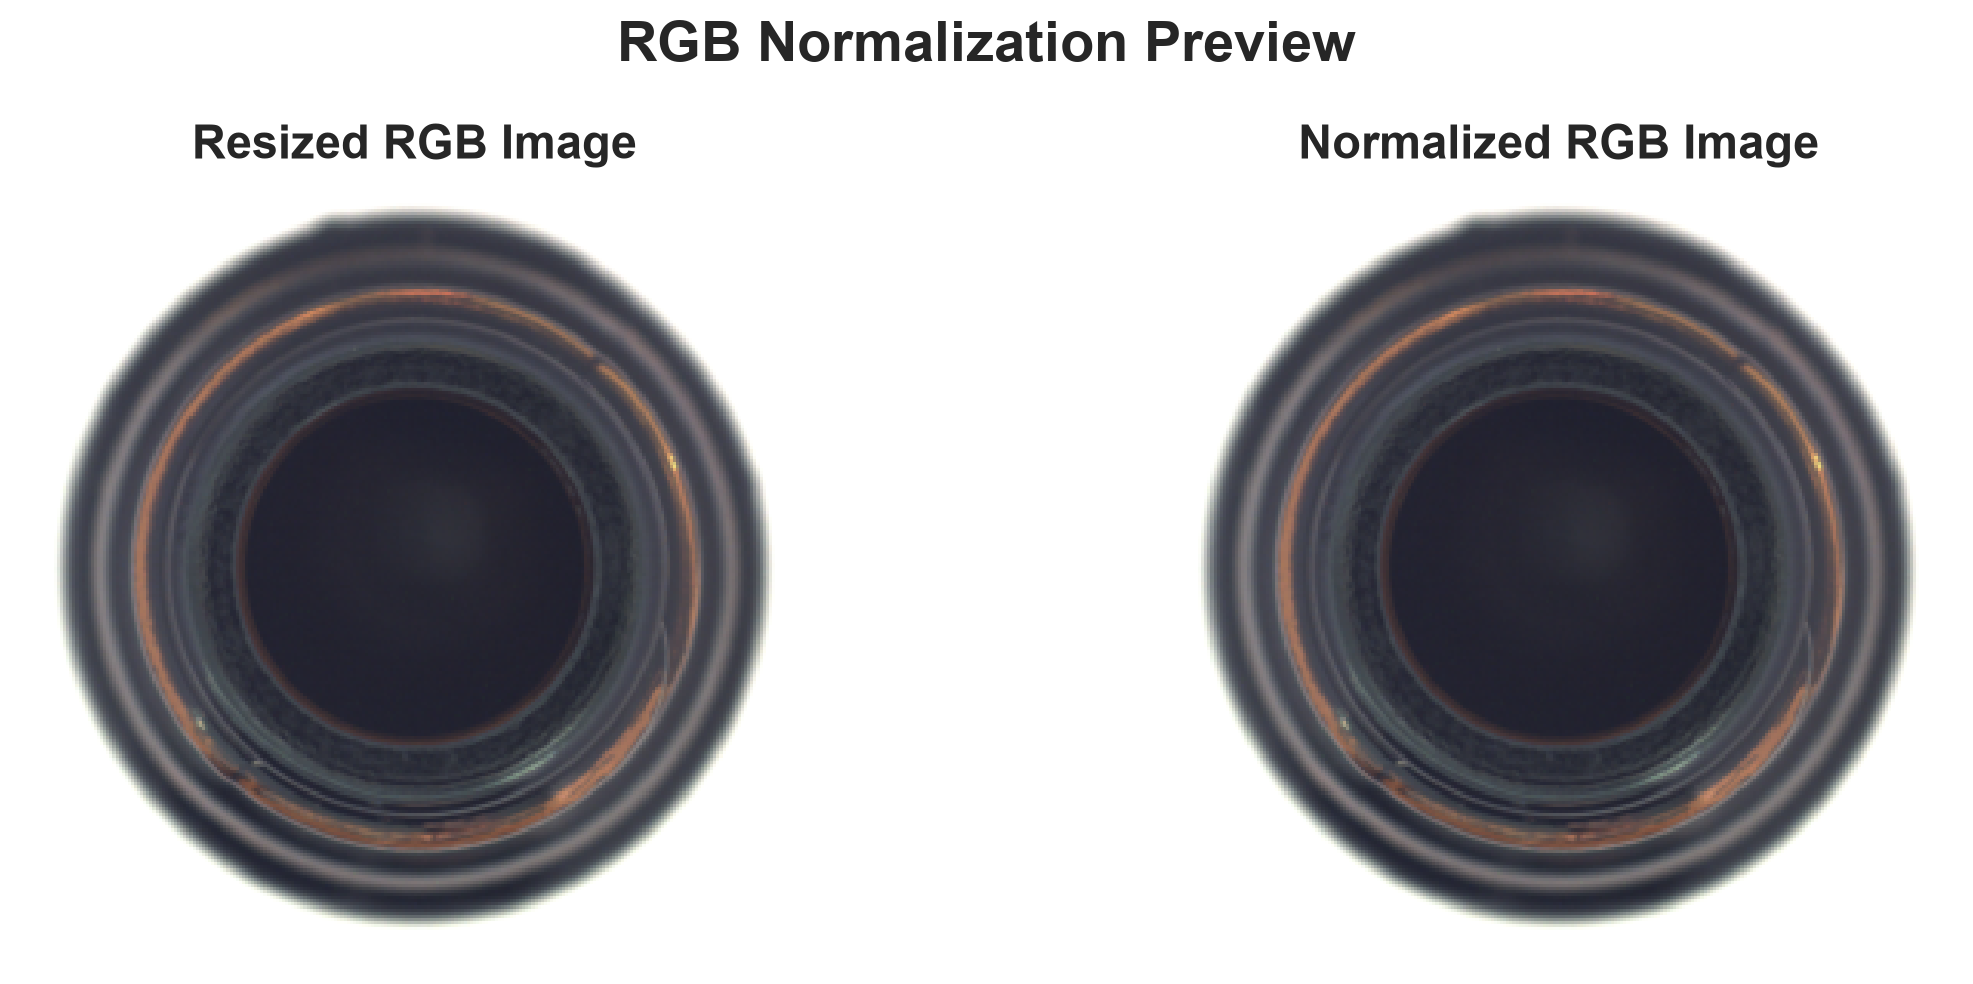

In [16]:
category = CATEGORIES[1]
image_files = get_image_files(
    RAW_ROOT / category / "train"
)

image = np.asarray(
    resize_rgb(
        load_rgb(image_files[0])
    )
)

normalized = image.astype(
    np.float32
) / 255.0

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].imshow(image.astype(np.uint8))
axes[0].set_title(
    "Resized RGB Image",
    fontweight="bold"
)

axes[1].imshow(normalized)
axes[1].set_title(
    "Normalized RGB Image",
    fontweight="bold"
)

for ax in axes:
    ax.axis("off")

plt.suptitle(
    "RGB Normalization Preview",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

save_static_figure(
    "tensorflow_normalization_preview.png"
)

show_saved_figure(
    "tensorflow_normalization_preview.png"
)

plt.close()


# Test Set Balance

Analyze normal and defective test images before preprocessing.


In [17]:
test_balance = (
    test_df.assign(
        Class=np.where(
            test_df["Anomaly Label"] == 0,
            "Normal",
            "Defective"
        )
    )
    .groupby(["Category", "Class"])
    .size()
    .reset_index(name="Images")
)

display(test_balance)


,Category,Class,Images
0,bottle,Defective,63
1,bottle,Normal,20
2,capsule,Defective,109
3,capsule,Normal,23
4,hazelnut,Defective,70
5,hazelnut,Normal,40
6,metal_nut,Defective,93
7,metal_nut,Normal,22
8,screw,Defective,119
9,screw,Normal,41


# Test Balance Visualization


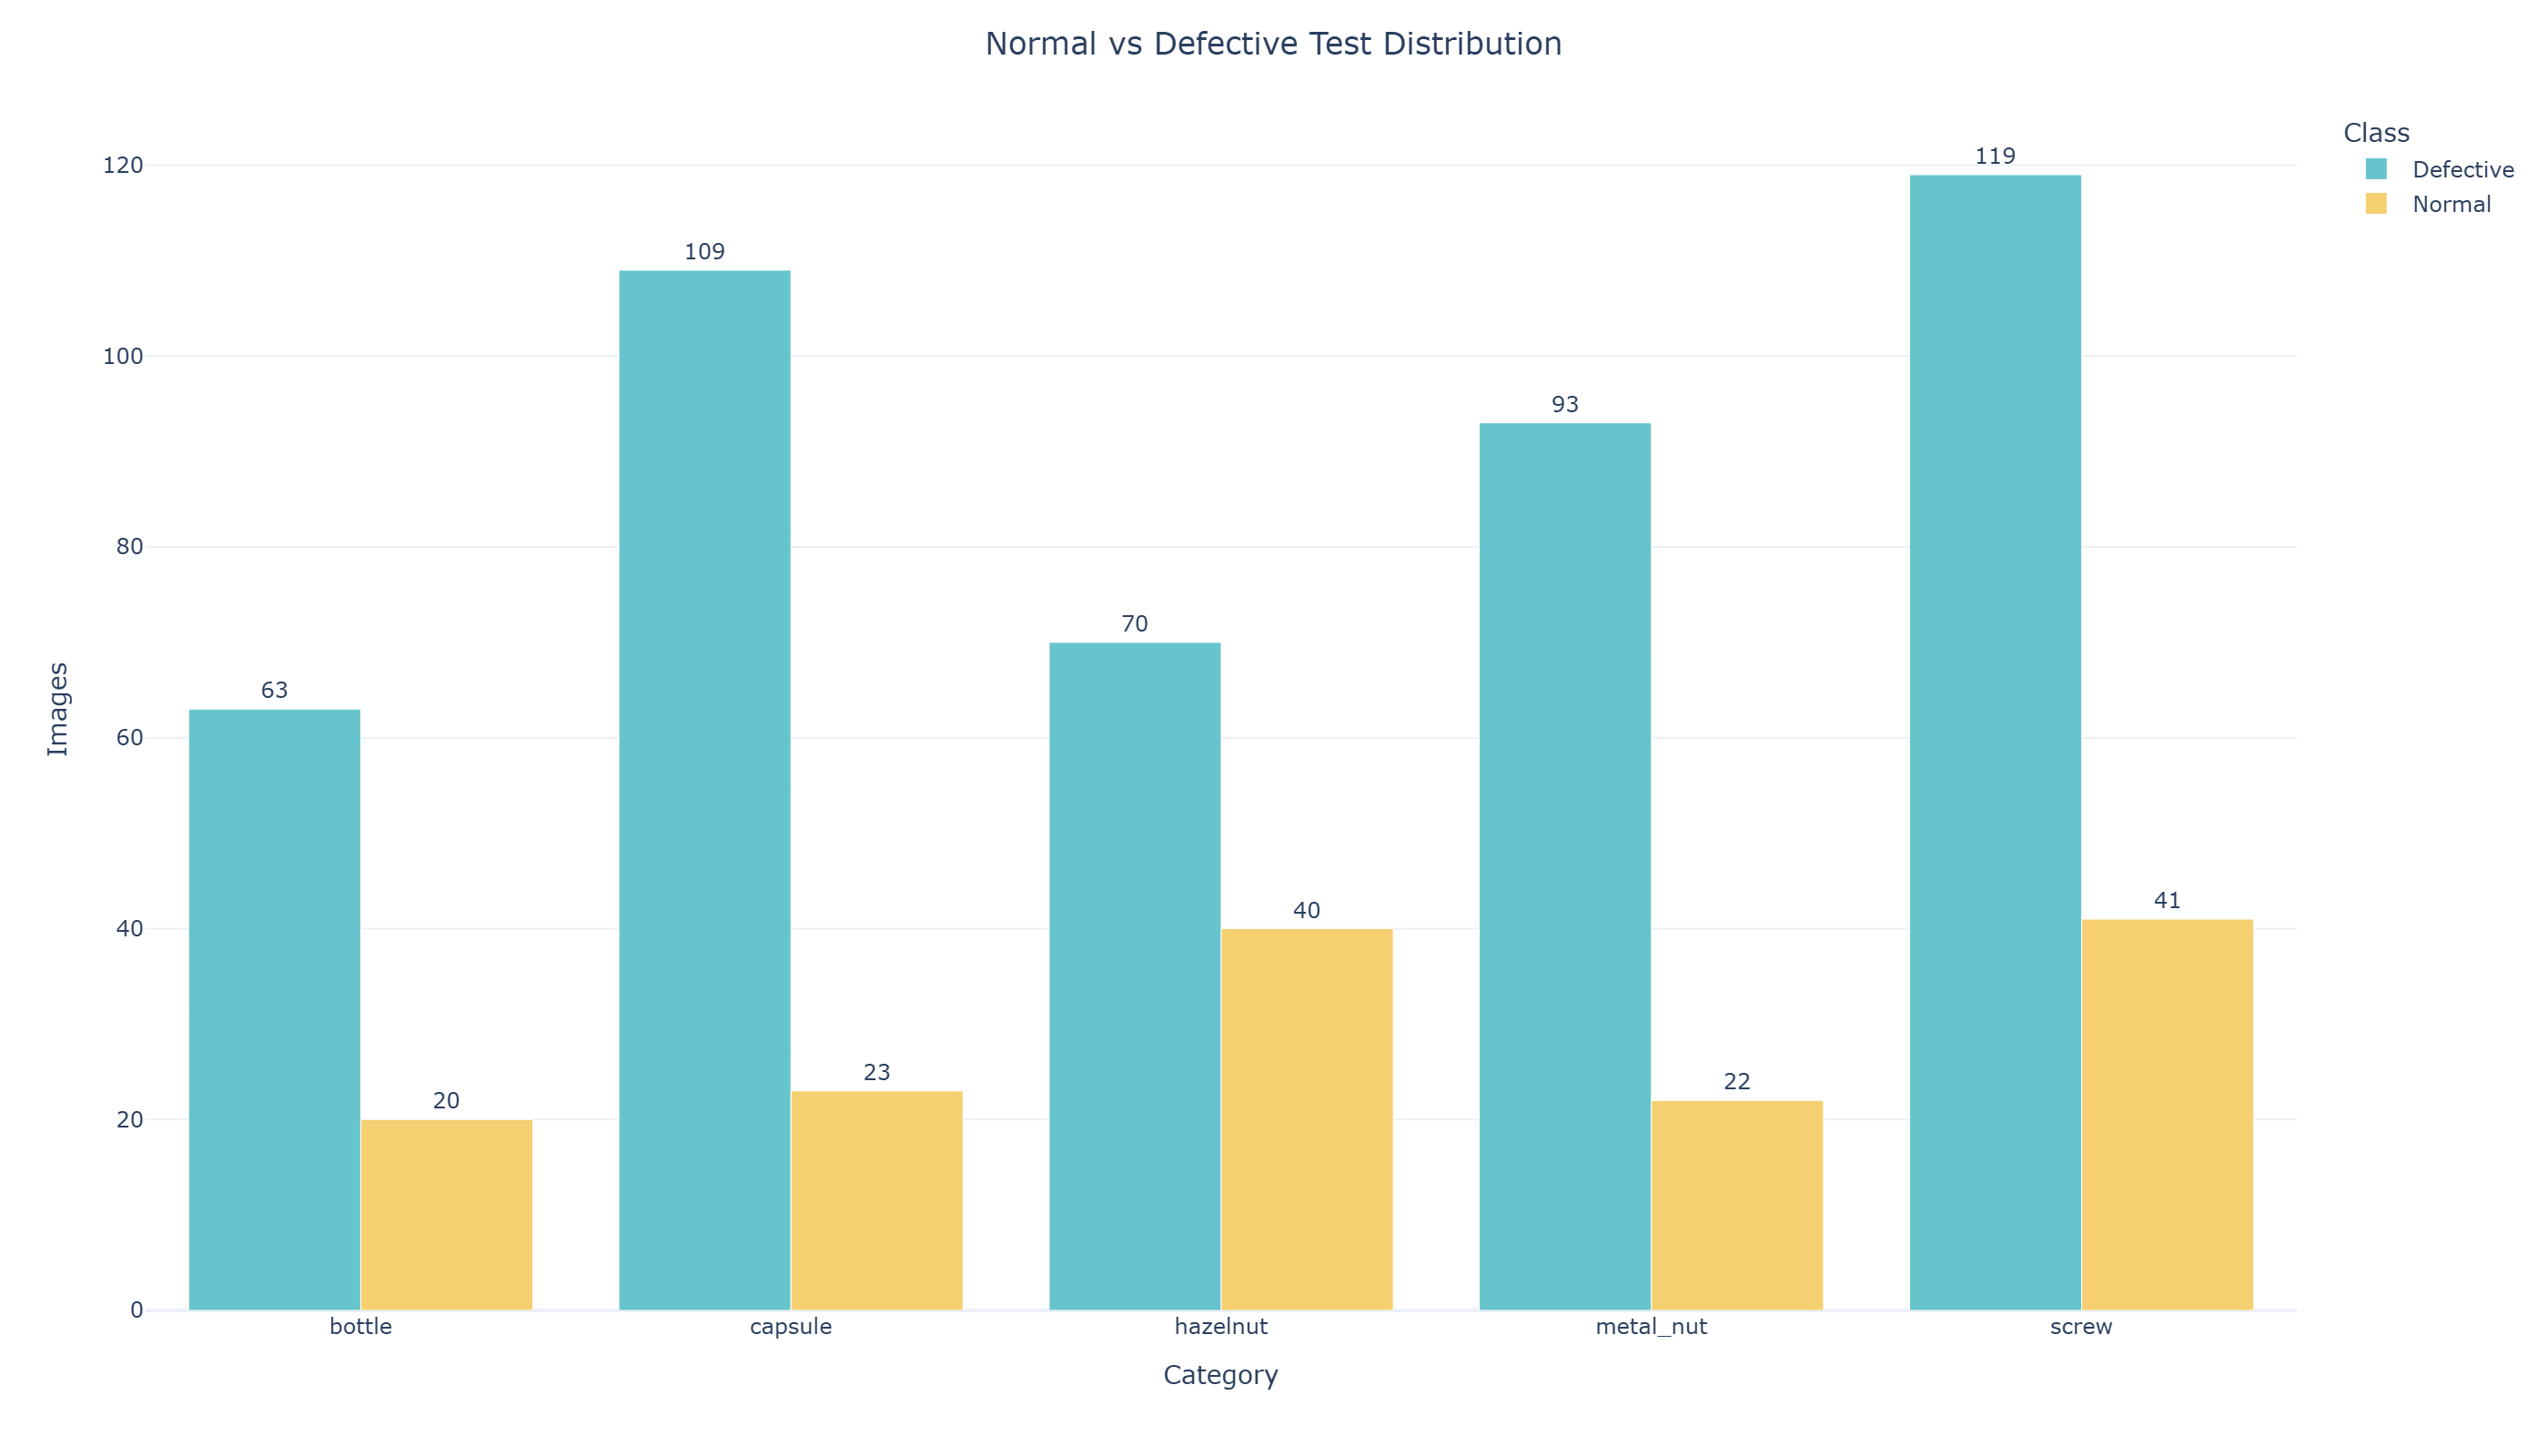

In [18]:
fig = px.bar(
    test_balance,
    x="Category",
    y="Images",
    color="Class",
    barmode="group",
    text="Images",
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textposition="outside")

fig.update_layout(
    title={"text": "Normal vs Defective Test Distribution", "x": 0.5},
    template="plotly_white",
    xaxis_title="Category",
    yaxis_title="Images",
    width=1200,
    height=700
)

export_plotly(
    fig,
    "tensorflow_test_balance"
)

show_saved_figure(
    "tensorflow_test_balance.png"
)


# Defect Type Distribution


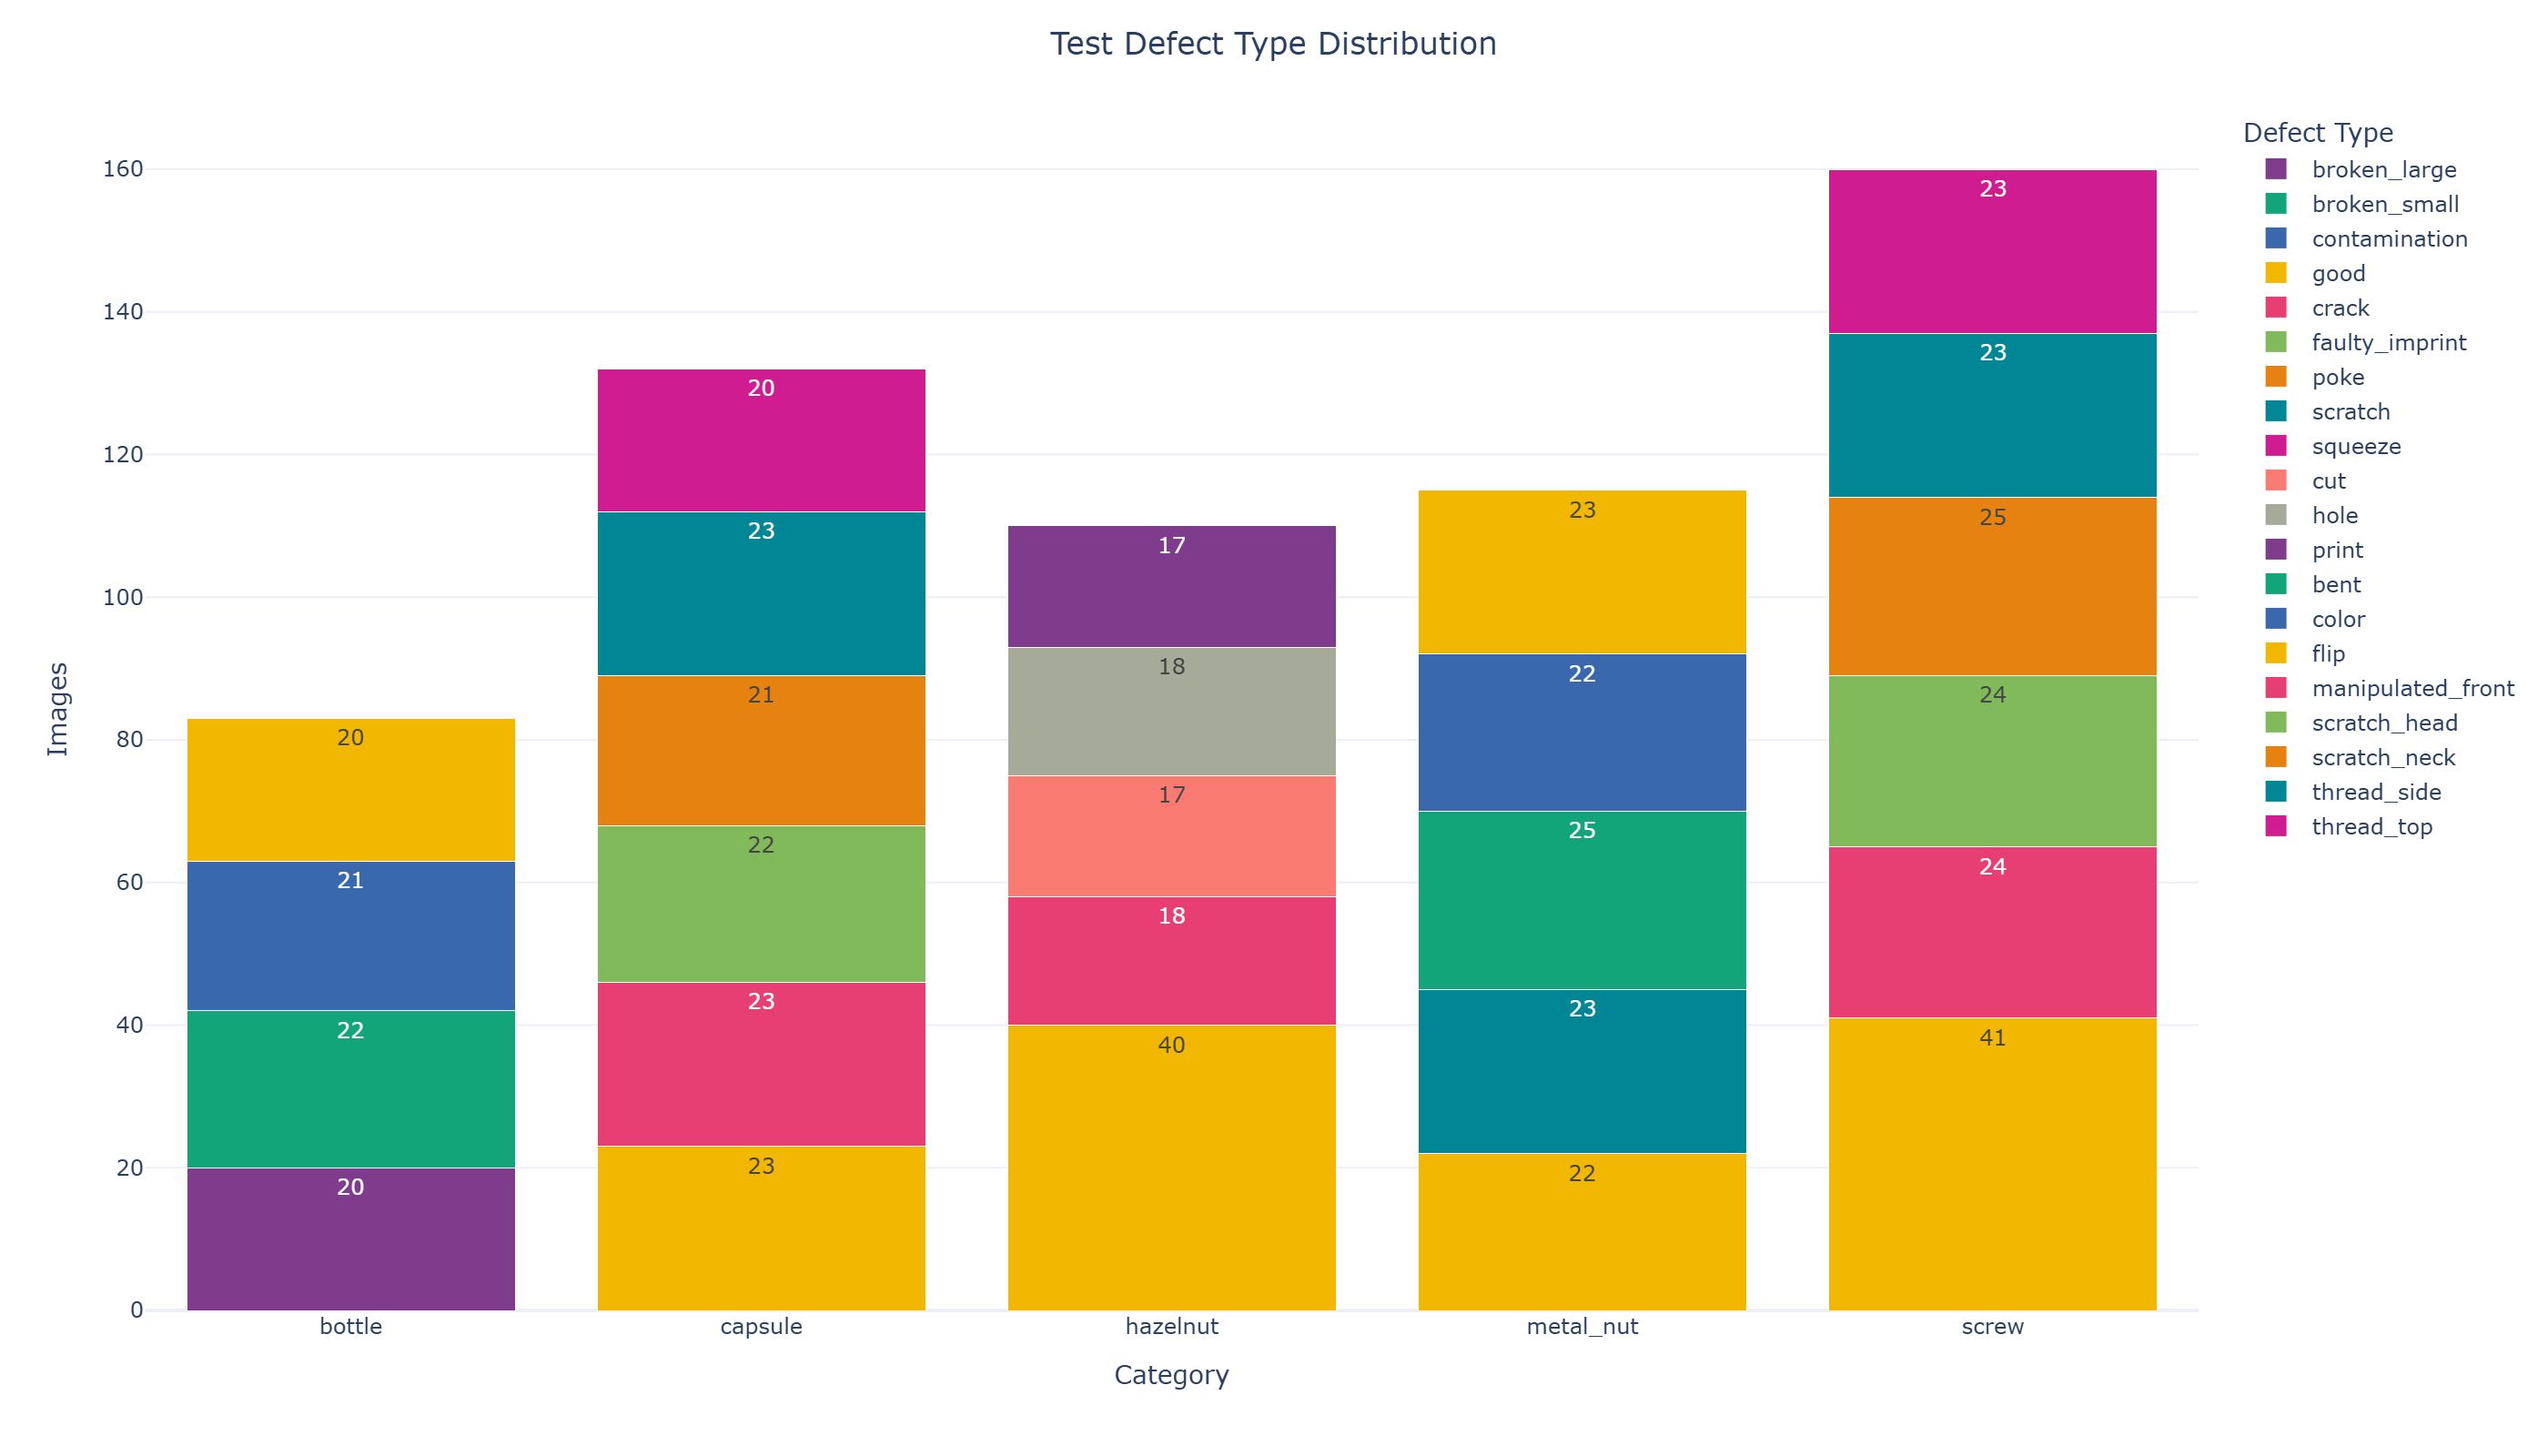

In [19]:
defect_distribution = (
    test_df
    .groupby(["Category", "Defect Type"])
    .size()
    .reset_index(name="Images")
)

fig = px.bar(
    defect_distribution,
    x="Category",
    y="Images",
    color="Defect Type",
    barmode="stack",
    text="Images",
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_traces(textposition="inside")

fig.update_layout(
    title={"text": "Test Defect Type Distribution", "x": 0.5},
    template="plotly_white",
    xaxis_title="Category",
    yaxis_title="Images",
    width=1400,
    height=800
)

export_plotly(
    fig,
    "tensorflow_defect_distribution"
)

show_saved_figure(
    "tensorflow_defect_distribution.png"
)


# Image Resolution Analysis


In [20]:
dimension_records = []

for category in CATEGORIES:
    files = (
        get_image_files(
            RAW_ROOT / category / "train"
        )
        + get_image_files(
            RAW_ROOT / category / "test"
        )
    )

    for image_path in files:
        try:
            with Image.open(image_path) as image:
                width, height = image.size

            dimension_records.append({
                "Category": category,
                "Filename": image_path.name,
                "Width": width,
                "Height": height,
                "Area": width * height,
                "Aspect Ratio": width / height
            })
        except Exception:
            pass

dimensions_df = pd.DataFrame(
    dimension_records
)

dimension_summary = (
    dimensions_df
    .groupby("Category")
    .agg(
        Images=("Filename", "count"),
        Mean_Width=("Width", "mean"),
        Mean_Height=("Height", "mean"),
        Min_Width=("Width", "min"),
        Max_Width=("Width", "max"),
        Min_Height=("Height", "min"),
        Max_Height=("Height", "max"),
        Mean_Aspect_Ratio=("Aspect Ratio", "mean")
    )
    .reset_index()
)

display(
    dimension_summary.round(3)
)


,Category,Images,Mean_Width,Mean_Height,Min_Width,Max_Width,Min_Height,Max_Height,Mean_Aspect_Ratio
0,bottle,292,900.0,900.0,900,900,900,900,1.0
1,capsule,351,1000.0,1000.0,1000,1000,1000,1000,1.0
2,hazelnut,501,1024.0,1024.0,1024,1024,1024,1024,1.0
3,metal_nut,335,700.0,700.0,700,700,700,700,1.0
4,screw,480,1024.0,1024.0,1024,1024,1024,1024,1.0


# Resolution Landscape


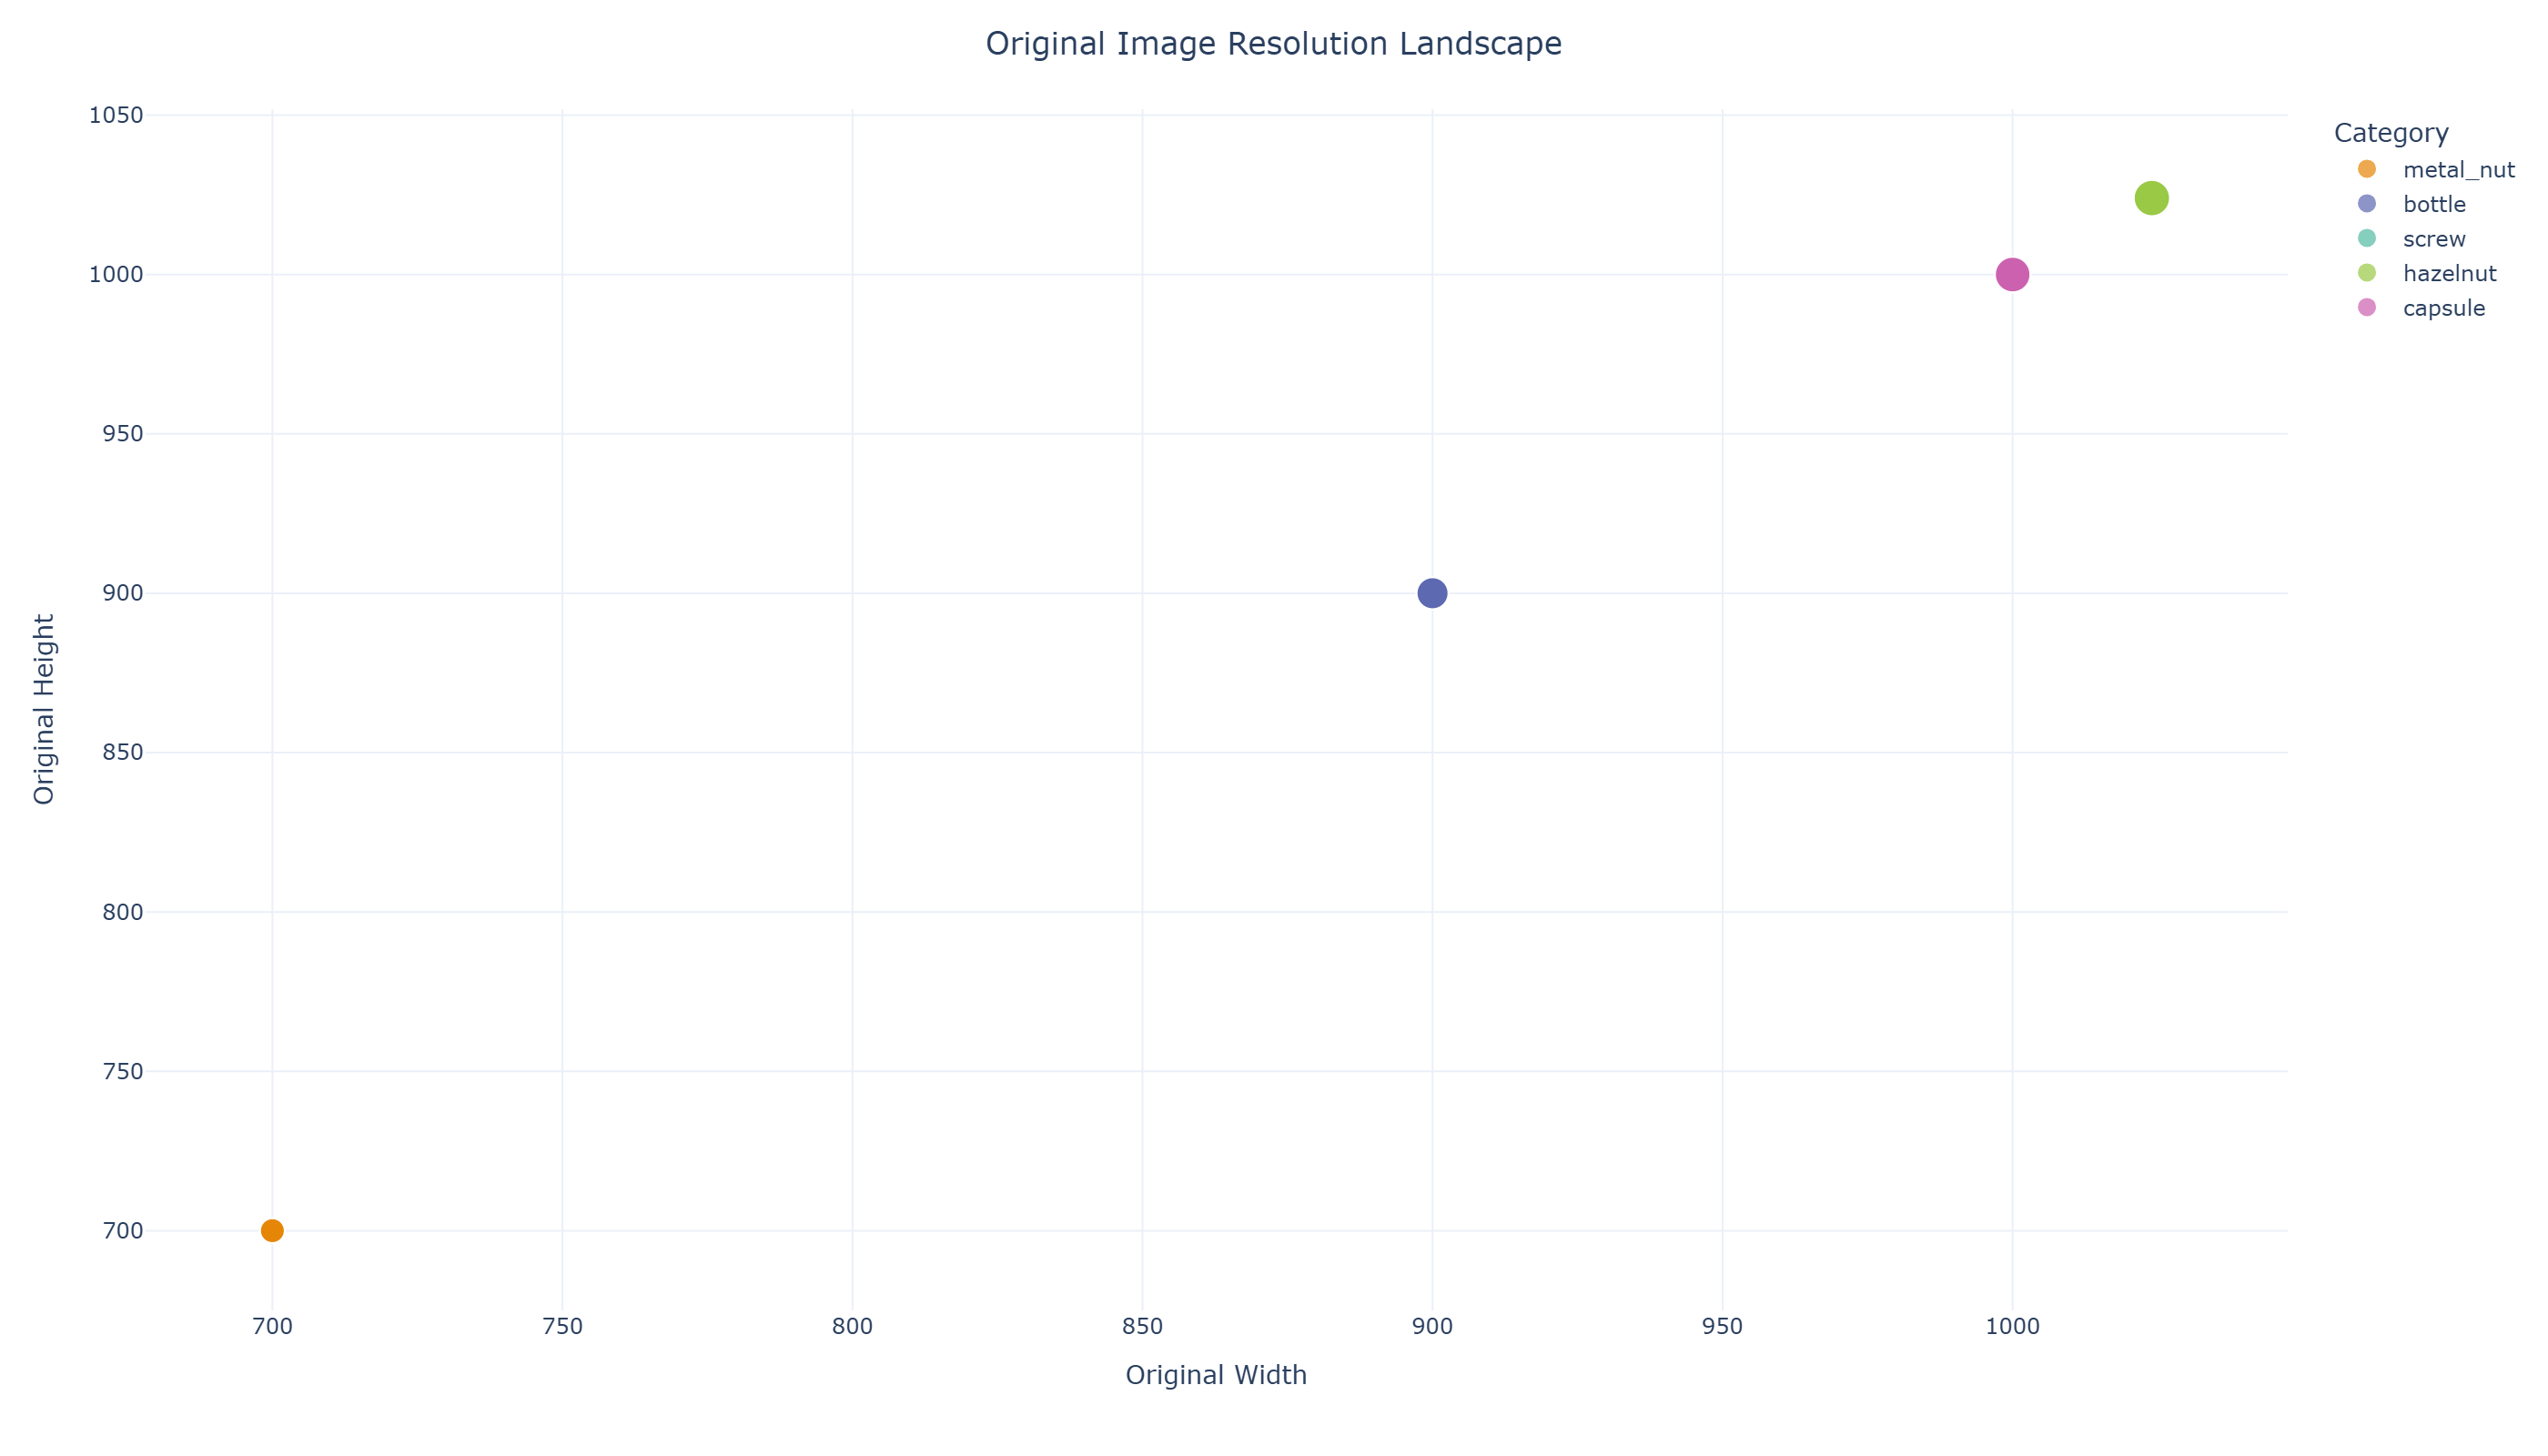

In [21]:
sample_dimensions = dimensions_df.sample(
    min(3000, len(dimensions_df)),
    random_state=42
)

fig = px.scatter(
    sample_dimensions,
    x="Width",
    y="Height",
    color="Category",
    size="Area",
    hover_data=["Aspect Ratio"],
    color_discrete_sequence=px.colors.qualitative.Vivid
)

fig.update_layout(
    title={"text": "Original Image Resolution Landscape", "x": 0.5},
    template="plotly_white",
    xaxis_title="Original Width",
    yaxis_title="Original Height",
    width=1200,
    height=750
)

export_plotly(
    fig,
    "tensorflow_resolution_landscape"
)

show_saved_figure(
    "tensorflow_resolution_landscape.png"
)


# Ground-Truth Mask Processing

Resize masks with nearest-neighbor interpolation and measure defect coverage.


In [22]:
mask_records = []

for category in CATEGORIES:
    mask_files = get_image_files(
        RAW_ROOT / category / "ground_truth"
    )

    for mask_path in mask_files:
        mask = resize_mask(
            load_gray(mask_path)
        )

        mask_array = np.asarray(mask)
        binary = mask_array > 0

        mask_records.append({
            "Category": category,
            "Filename": mask_path.name,
            "Defect Pixels": int(binary.sum()),
            "Coverage (%)": float(binary.mean() * 100),
            "Width": mask.width,
            "Height": mask.height
        })

mask_df = pd.DataFrame(
    mask_records
)

display(
    mask_df.head(10)
)


,Category,Filename,Defect Pixels,Coverage (%),Width,Height
0,screw,000_mask.png,238,0.363159,256,256
1,screw,001_mask.png,182,0.277710,256,256
2,screw,002_mask.png,162,0.247192,256,256
3,screw,003_mask.png,300,0.457764,256,256
4,screw,004_mask.png,139,0.212097,256,256
5,screw,005_mask.png,207,0.315857,256,256
6,screw,006_mask.png,222,0.338745,256,256
7,screw,007_mask.png,309,0.471497,256,256
8,screw,008_mask.png,234,0.357056,256,256
9,screw,009_mask.png,417,0.636292,256,256


# Mask Coverage Visualization


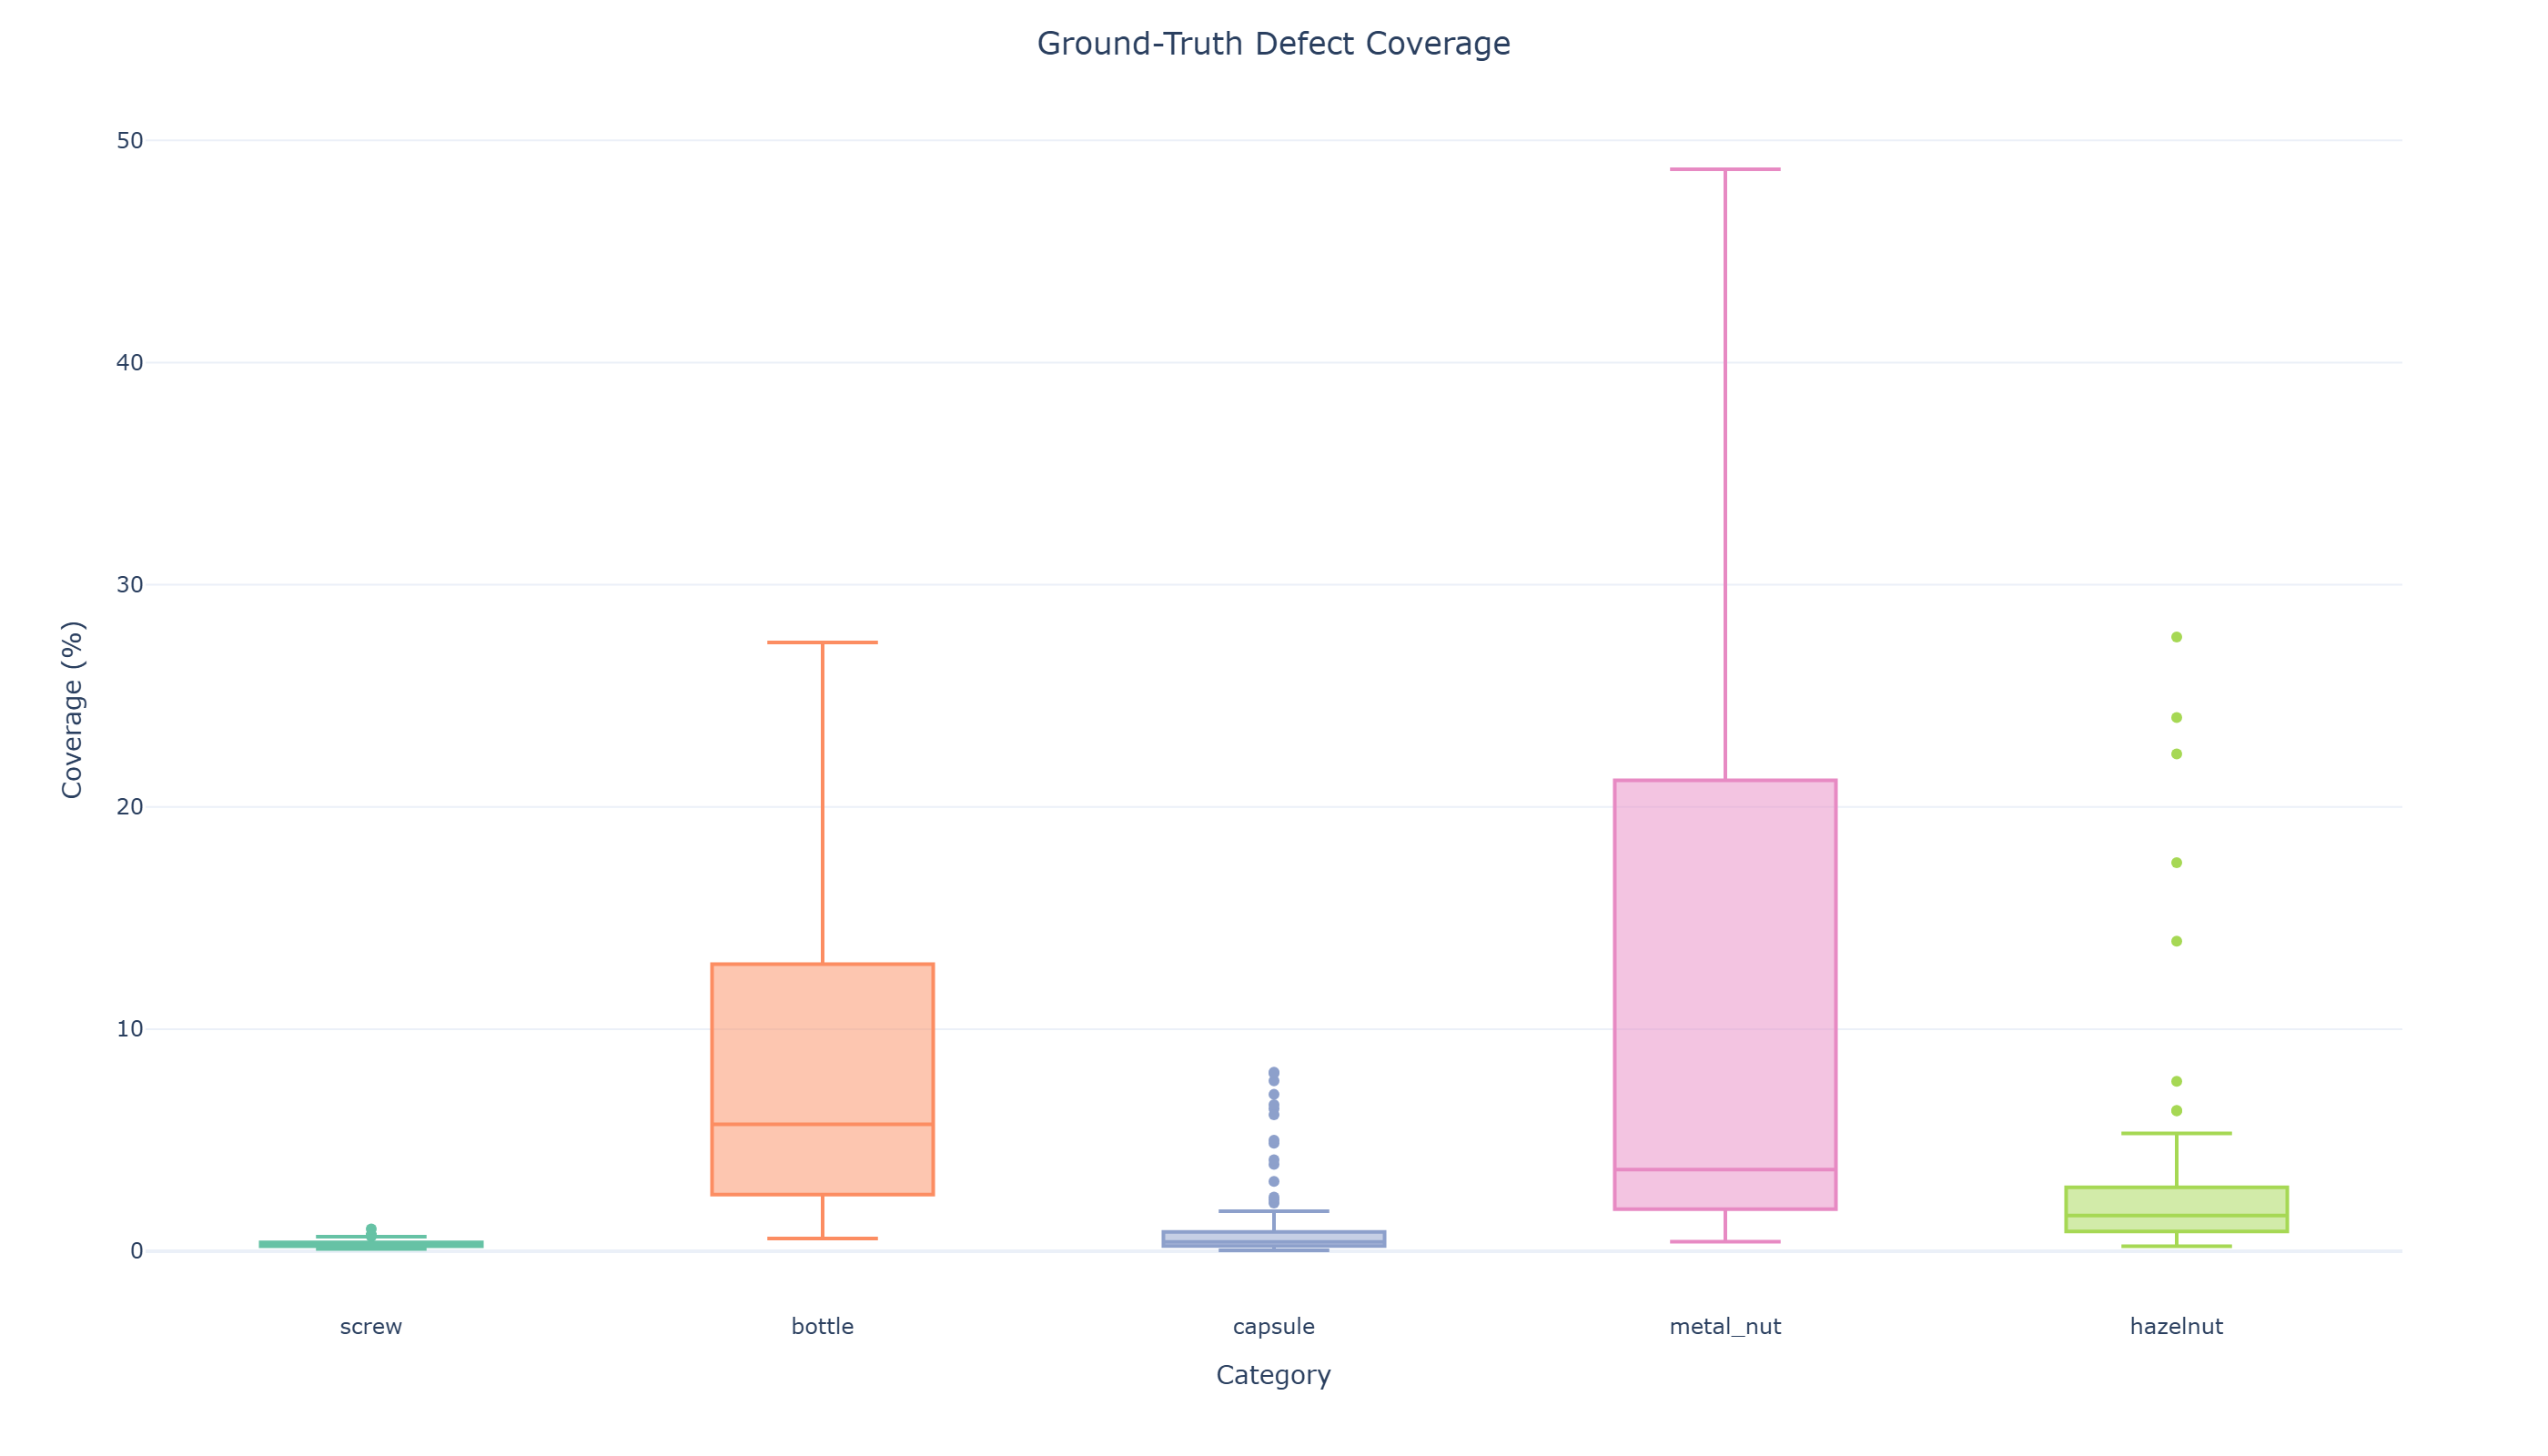

In [23]:
fig = px.box(
    mask_df,
    x="Category",
    y="Coverage (%)",
    color="Category",
    points="outliers",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    title={"text": "Ground-Truth Defect Coverage", "x": 0.5},
    template="plotly_white",
    xaxis_title="Category",
    yaxis_title="Coverage (%)",
    width=1200,
    height=700,
    showlegend=False
)

export_plotly(
    fig,
    "tensorflow_mask_coverage"
)

show_saved_figure(
    "tensorflow_mask_coverage.png"
)


# Mask Visualization


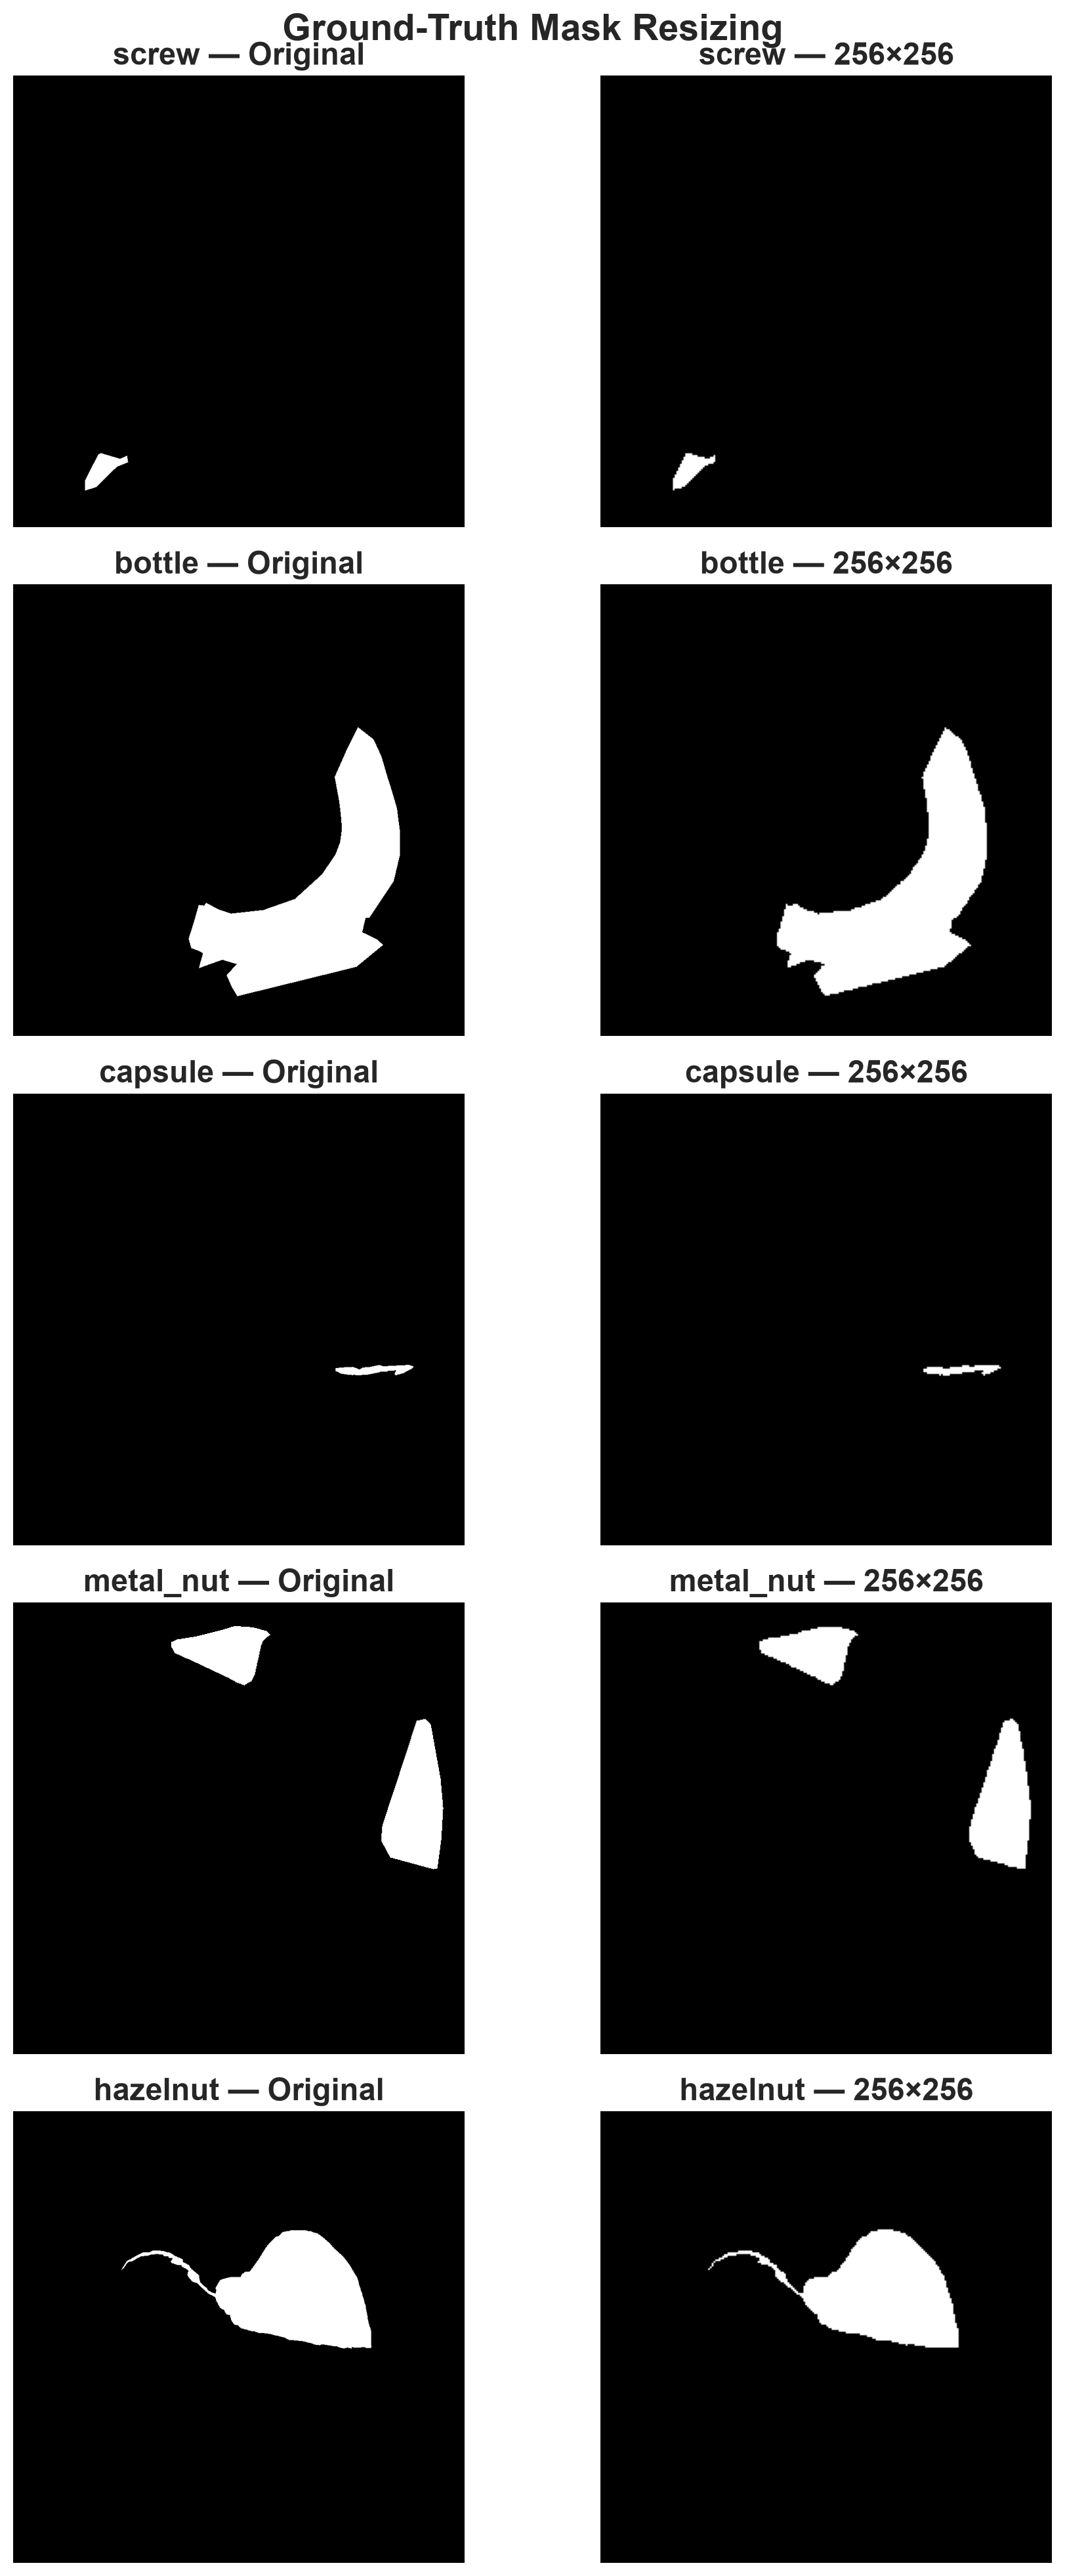

In [24]:
fig, axes = plt.subplots(
    len(CATEGORIES),
    2,
    figsize=(10, 4 * len(CATEGORIES))
)

for row, category in enumerate(CATEGORIES):
    mask_files = get_image_files(
        RAW_ROOT / category / "ground_truth"
    )

    if not mask_files:
        axes[row, 0].axis("off")
        axes[row, 1].axis("off")
        continue

    original_mask = load_gray(mask_files[0])
    resized = resize_mask(original_mask)

    axes[row, 0].imshow(
        original_mask,
        cmap="gray"
    )

    axes[row, 0].set_title(
        f"{category} — Original",
        fontweight="bold"
    )

    axes[row, 1].imshow(
        resized,
        cmap="gray"
    )

    axes[row, 1].set_title(
        f"{category} — {IMAGE_WIDTH}×{IMAGE_HEIGHT}",
        fontweight="bold"
    )

    axes[row, 0].axis("off")
    axes[row, 1].axis("off")

plt.suptitle(
    "Ground-Truth Mask Resizing",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

save_static_figure(
    "tensorflow_mask_resize.png"
)

show_saved_figure(
    "tensorflow_mask_resize.png"
)

plt.close()


# Processed RGB Export

Generate resized RGB images for train, validation, and test data.


In [25]:
def export_resized_image(
    source_path,
    destination
):
    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    image = resize_rgb(
        load_rgb(source_path)
    )

    image.save(
        destination,
        quality=95
    )

for _, row in train_split_df.iterrows():
    output = (
        TRAIN_ROOT /
        row["Category"] /
        row["Filename"]
    )
    export_resized_image(
        row["Image Path"],
        output
    )

for _, row in validation_df.iterrows():
    output = (
        VALIDATION_ROOT /
        row["Category"] /
        row["Filename"]
    )
    export_resized_image(
        row["Image Path"],
        output
    )

for _, row in test_df.iterrows():
    output = (
        TEST_ROOT /
        row["Category"] /
        row["Defect Type"] /
        row["Filename"]
    )
    export_resized_image(
        row["Image Path"],
        output
    )

print("Resized RGB dataset generated.")


Resized RGB dataset generated.


# Processed Mask Export

Export resized ground-truth masks using nearest-neighbor interpolation.


In [26]:
mask_export_records = []

for category in CATEGORIES:
    source_root = RAW_ROOT / category / "ground_truth"

    for mask_path in get_image_files(source_root):
        relative = mask_path.relative_to(
            source_root
        )

        destination = (
            MASK_ROOT /
            category /
            relative
        )

        destination.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        resized = resize_mask(
            load_gray(mask_path)
        )

        resized.save(
            destination
        )

        mask_export_records.append({
            "Category": category,
            "Filename": mask_path.name
        })

print(
    f"Processed masks generated: {len(mask_export_records):,}"
)


Processed masks generated: 454


# TensorFlow Dataset for Processed Images

Create a final `tf.data` pipeline over the processed training images.


In [27]:
processed_train_paths = [
    str(
        TRAIN_ROOT /
        category /
        filename
    )
    for category, filename in zip(
        train_split_df["Category"],
        train_split_df["Filename"]
    )
]

processed_validation_paths = [
    str(
        VALIDATION_ROOT /
        category /
        filename
    )
    for category, filename in zip(
        validation_df["Category"],
        validation_df["Filename"]
    )
]

processed_train_dataset = build_tf_dataset(
    processed_train_paths,
    training=True
)

processed_validation_dataset = build_tf_dataset(
    processed_validation_paths,
    training=False
)

processed_batch = next(
    iter(processed_train_dataset)
)

print("Processed TensorFlow batch shape:", tuple(processed_batch.shape))
print("Processed value range:", (
    float(tf.reduce_min(processed_batch)),
    float(tf.reduce_max(processed_batch))
))


Processed TensorFlow batch shape: (32, 256, 256, 3)
Processed value range: (0.0, 1.0)


# Processed Dataset Statistics


In [28]:
processed_records = []

for category in CATEGORIES:
    processed_records.append({
        "Category": category,
        "Train": count_images(
            TRAIN_ROOT / category
        ),
        "Validation": count_images(
            VALIDATION_ROOT / category
        ),
        "Test": count_images(
            TEST_ROOT / category
        ),
        "Masks": count_images(
            MASK_ROOT / category
        )
    })

processed_stats_df = pd.DataFrame(
    processed_records
)

display(
    processed_stats_df.style
    .hide(axis="index")
    .background_gradient(
        cmap="PuBuGn"
    )
)


Category,Train,Validation,Test,Masks
screw,256,64,160,119
bottle,167,42,83,63
capsule,175,44,132,109
metal_nut,176,44,115,93
hazelnut,312,79,110,70


# Preprocessed Sample Gallery


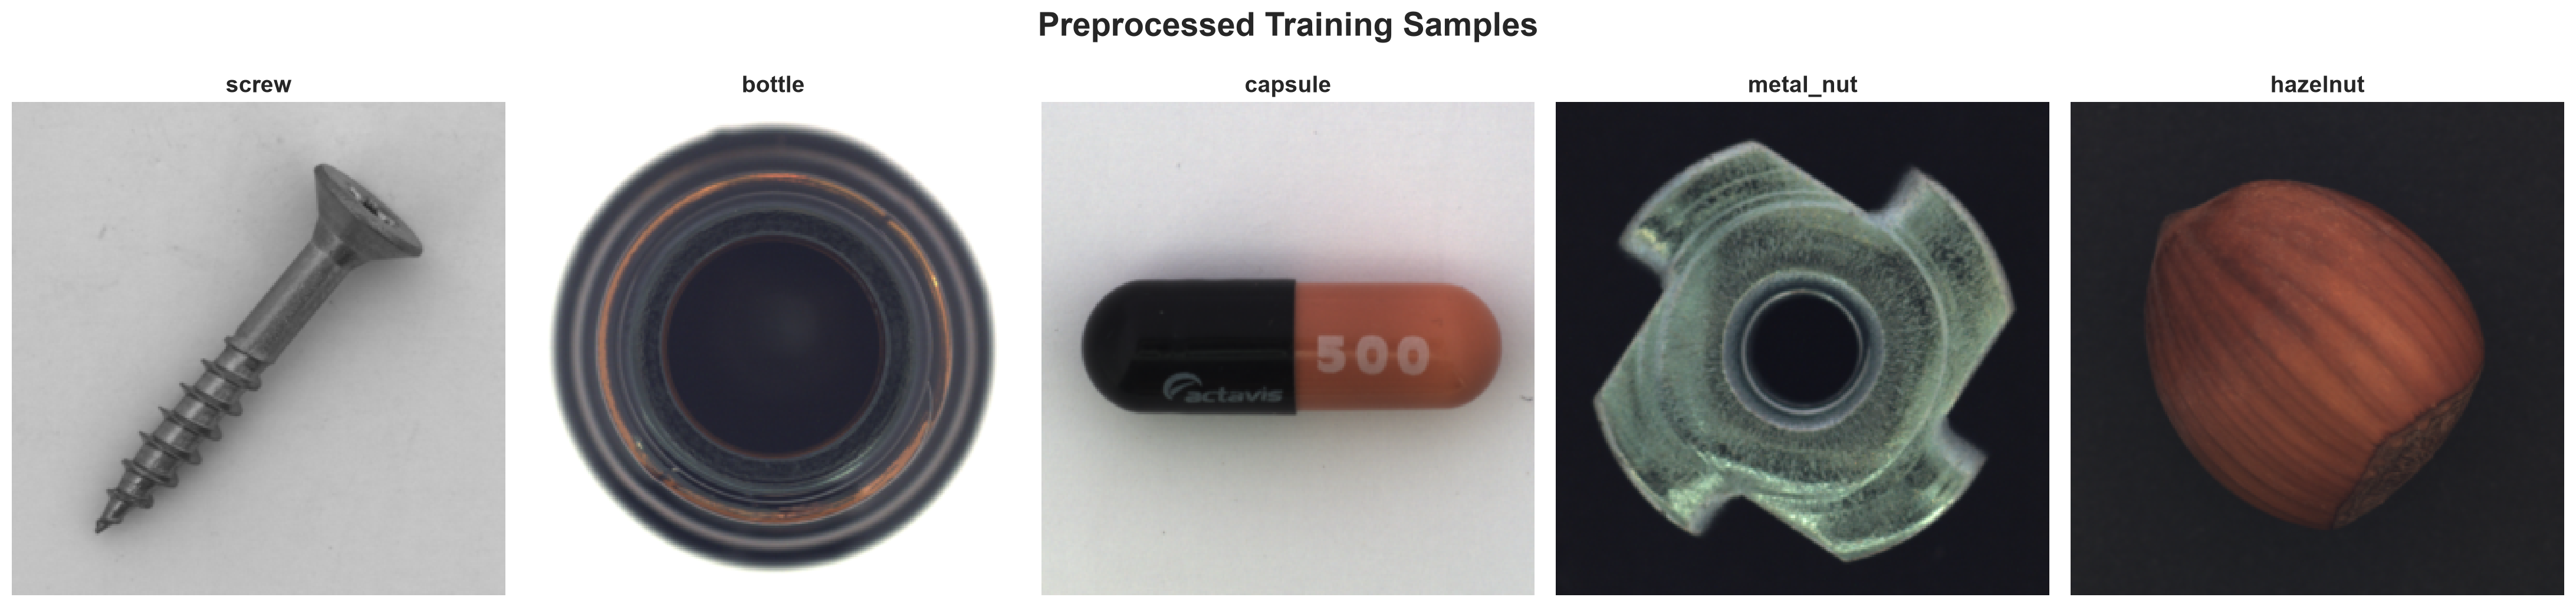

In [29]:
fig, axes = plt.subplots(
    1,
    len(CATEGORIES),
    figsize=(22, 5.5)
)

for index, category in enumerate(CATEGORIES):
    files = get_image_files(
        TRAIN_ROOT / category
    )

    ax = axes[index]

    if files:
        ax.imshow(
            load_rgb(files[0])
        )
        ax.set_title(
            category,
            fontsize=14,
            fontweight="bold"
        )
    else:
        ax.text(
            0.5,
            0.5,
            "Unavailable",
            ha="center",
            va="center"
        )

    ax.axis("off")

plt.suptitle(
    "Preprocessed Training Samples",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

save_static_figure(
    "processed_training_samples.png"
)

show_saved_figure(
    "processed_training_samples.png"
)

plt.close()


# Preprocessed Storage Analysis


In [30]:
def folder_size_gb(folder):
    total = 0

    for file_path in Path(folder).rglob("*"):
        if file_path.is_file():
            total += file_path.stat().st_size

    return total / (1024 ** 3)

storage_df = pd.DataFrame([
    {
        "Component": "Train",
        "Size GB": folder_size_gb(TRAIN_ROOT)
    },
    {
        "Component": "Validation",
        "Size GB": folder_size_gb(VALIDATION_ROOT)
    },
    {
        "Component": "Test",
        "Size GB": folder_size_gb(TEST_ROOT)
    },
    {
        "Component": "Masks",
        "Size GB": folder_size_gb(MASK_ROOT)
    }
])

display(
    storage_df.style
    .hide(axis="index")
    .format({
        "Size GB": "{:.4f}"
    })
)


Component,Size GB
Train,0.0704
Validation,0.0177
Test,0.0388
Masks,0.0002


# Processed Storage Visualization


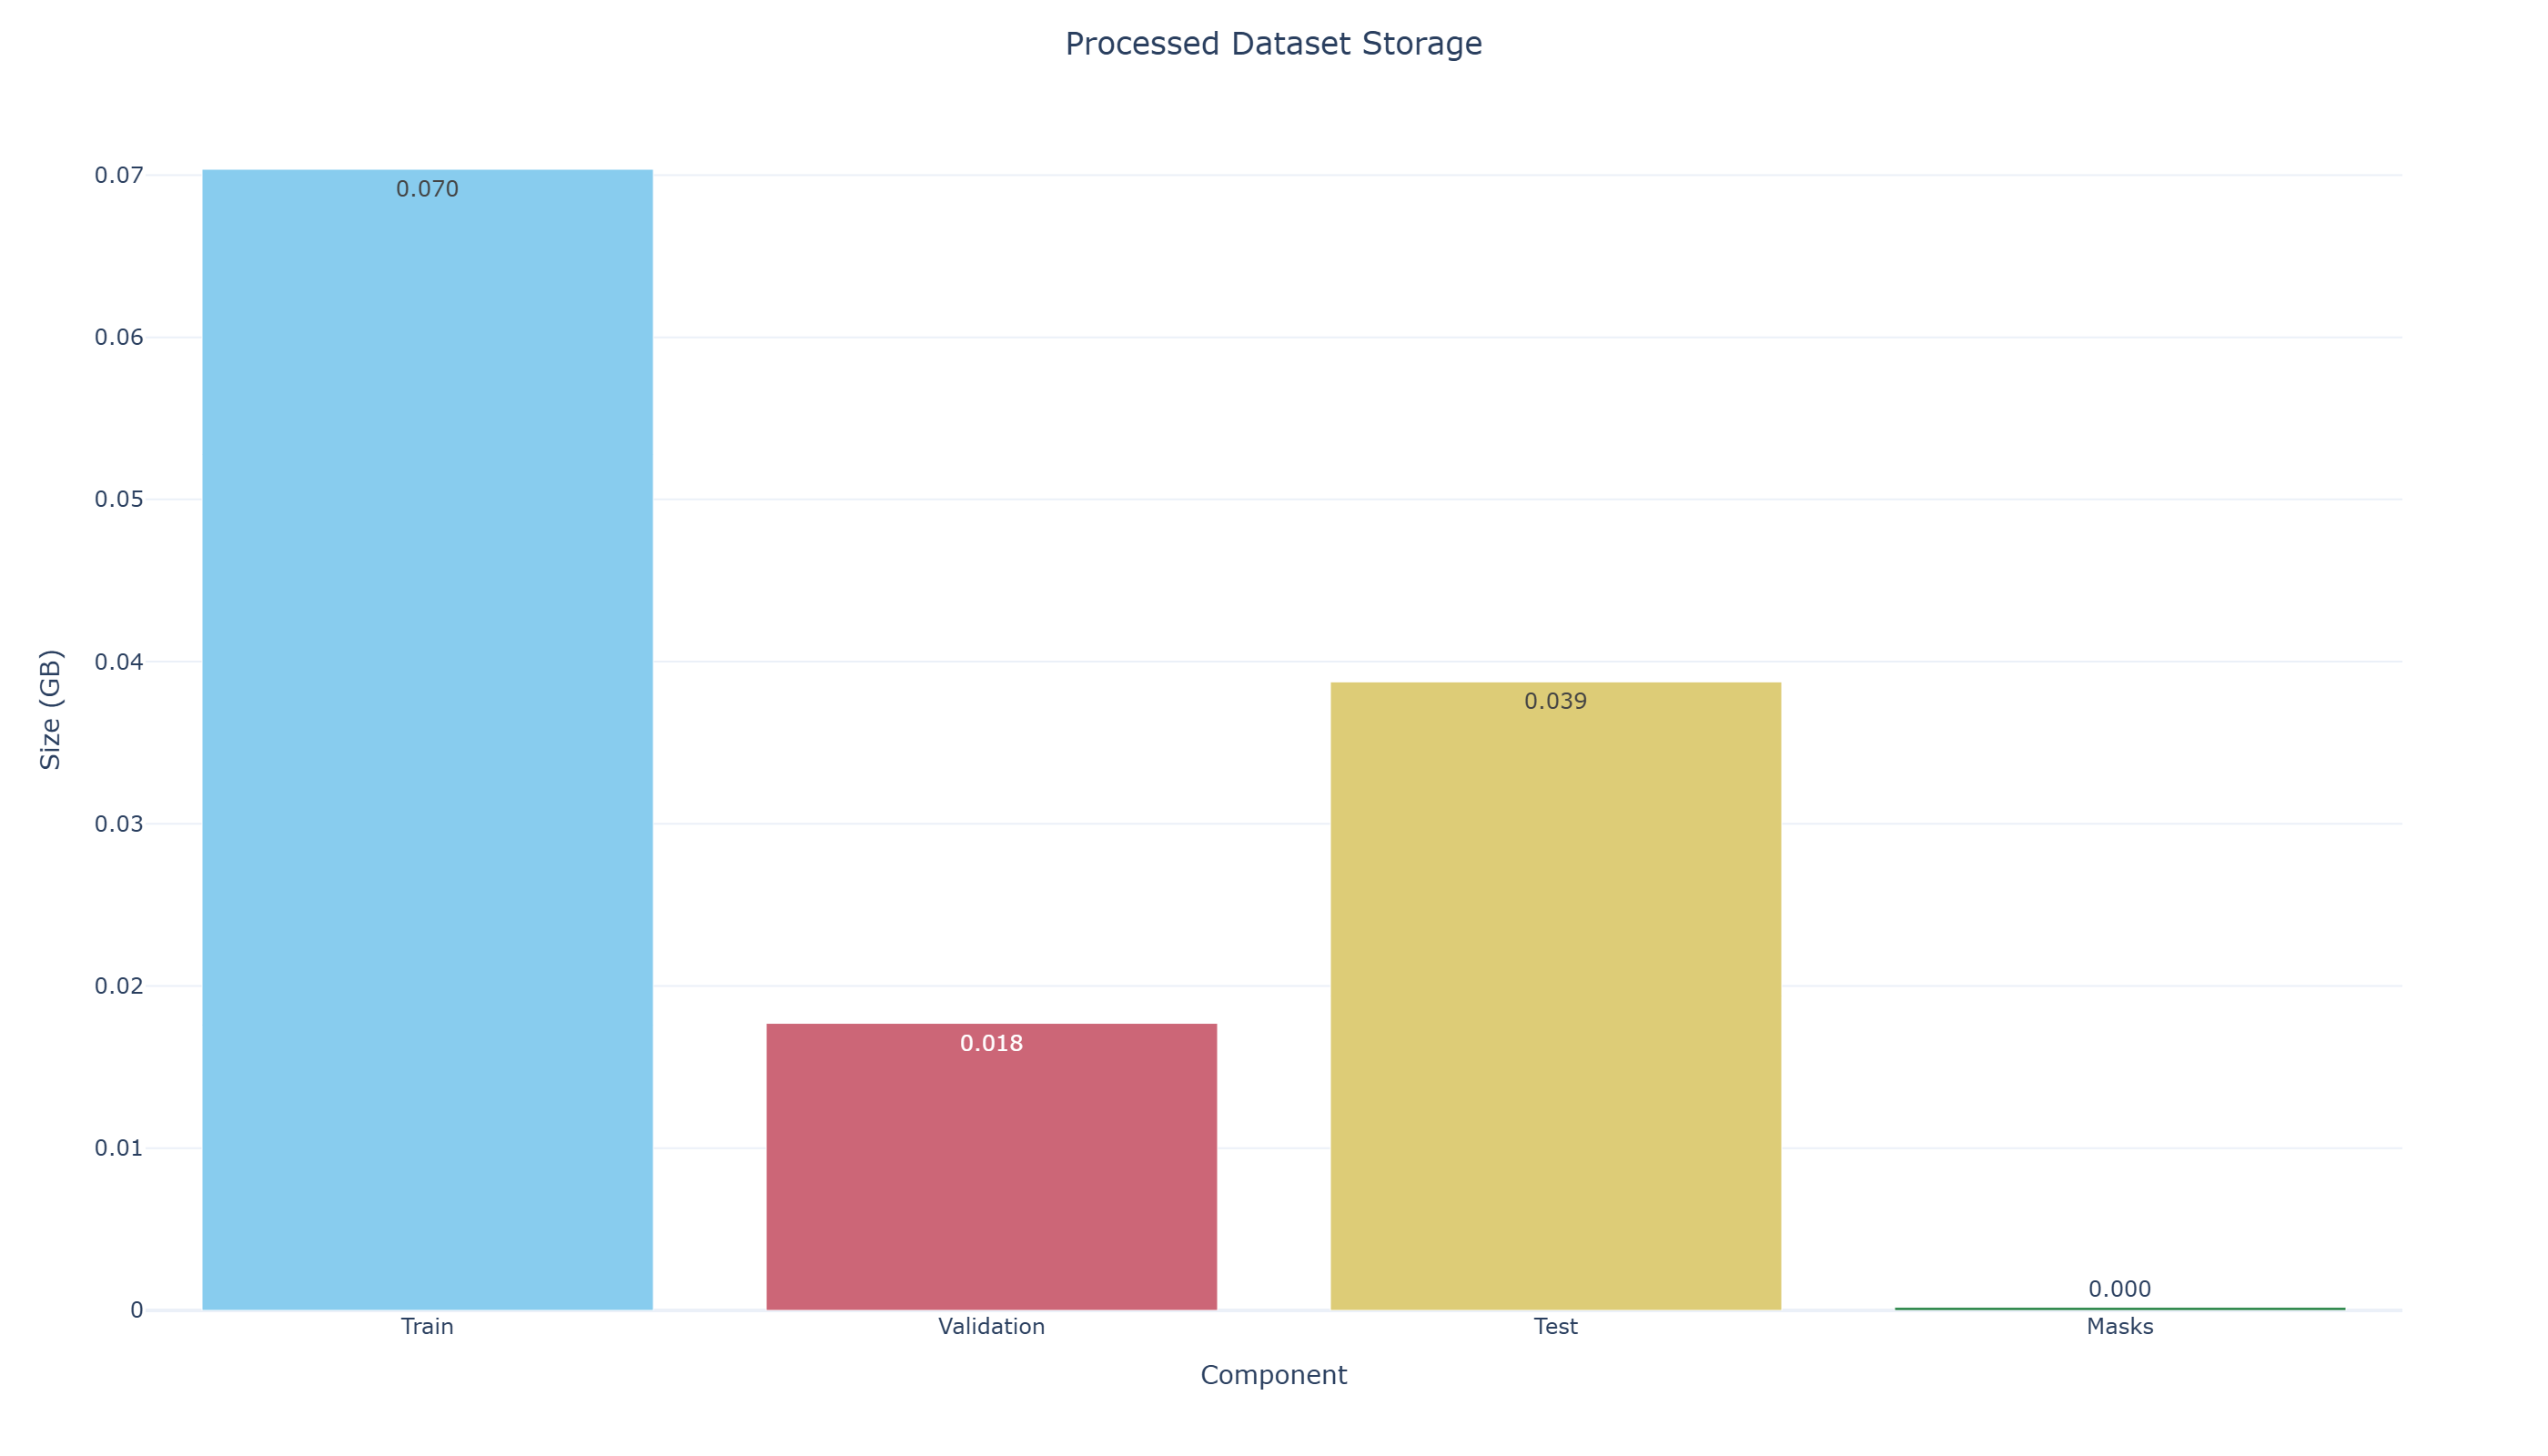

In [31]:
fig = px.bar(
    storage_df,
    x="Component",
    y="Size GB",
    color="Component",
    text_auto=".3f",
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_layout(
    title={"text": "Processed Dataset Storage", "x": 0.5},
    template="plotly_white",
    xaxis_title="Component",
    yaxis_title="Size (GB)",
    width=1100,
    height=650,
    showlegend=False
)

export_plotly(
    fig,
    "tensorflow_processed_storage"
)

show_saved_figure(
    "tensorflow_processed_storage.png"
)


# Save Manifests and Analysis Tables


In [32]:
train_split_df.drop(
    columns=["Image Path"]
).to_csv(
    PROCESSED_ROOT / "train_manifest.csv",
    index=False
)

validation_df.drop(
    columns=["Image Path"]
).to_csv(
    PROCESSED_ROOT / "validation_manifest.csv",
    index=False
)

test_df.drop(
    columns=["Image Path"]
).to_csv(
    PROCESSED_ROOT / "test_manifest.csv",
    index=False
)

split_summary.to_csv(
    PROCESSED_ROOT / "split_summary.csv",
    index=False
)

test_balance.to_csv(
    PROCESSED_ROOT / "test_balance.csv",
    index=False
)

defect_distribution.to_csv(
    PROCESSED_ROOT / "defect_distribution.csv",
    index=False
)

dimension_summary.to_csv(
    PROCESSED_ROOT / "dimension_summary.csv",
    index=False
)

mask_df.to_csv(
    PROCESSED_ROOT / "mask_statistics.csv",
    index=False
)

processed_stats_df.to_csv(
    PROCESSED_ROOT / "processed_statistics.csv",
    index=False
)

storage_df.to_csv(
    PROCESSED_ROOT / "storage_statistics.csv",
    index=False
)

print("Preprocessing tables and manifests saved.")


Preprocessing tables and manifests saved.


# Final Validation


In [33]:
validation_records = []

for category in CATEGORIES:
    train_count = count_images(
        TRAIN_ROOT / category
    )
    validation_count = count_images(
        VALIDATION_ROOT / category
    )
    test_count = count_images(
        TEST_ROOT / category
    )
    mask_count = count_images(
        MASK_ROOT / category
    )

    validation_records.append({
        "Category": category,
        "Train": train_count,
        "Validation": validation_count,
        "Test": test_count,
        "Masks": mask_count
    })

final_counts_df = pd.DataFrame(
    validation_records
)

display(
    final_counts_df.style
    .hide(axis="index")
    .background_gradient(
        cmap="Blues"
    )
)

counts_ok = (
    final_counts_df["Train"].eq(
        split_summary["Train"]
    ).all()
    and
    final_counts_df["Validation"].eq(
        split_summary["Validation"]
    ).all()
    and
    final_counts_df["Test"].gt(0).all()
    and
    final_counts_df["Masks"].gt(0).all()
)

print(
    "Preprocessing validation passed."
    if counts_ok
    else
    "Preprocessing validation requires review."
)


Category,Train,Validation,Test,Masks
screw,256,64,160,119
bottle,167,42,83,63
capsule,175,44,132,109
metal_nut,176,44,115,93
hazelnut,312,79,110,70


Preprocessing validation passed.


# Preprocessing Dashboard


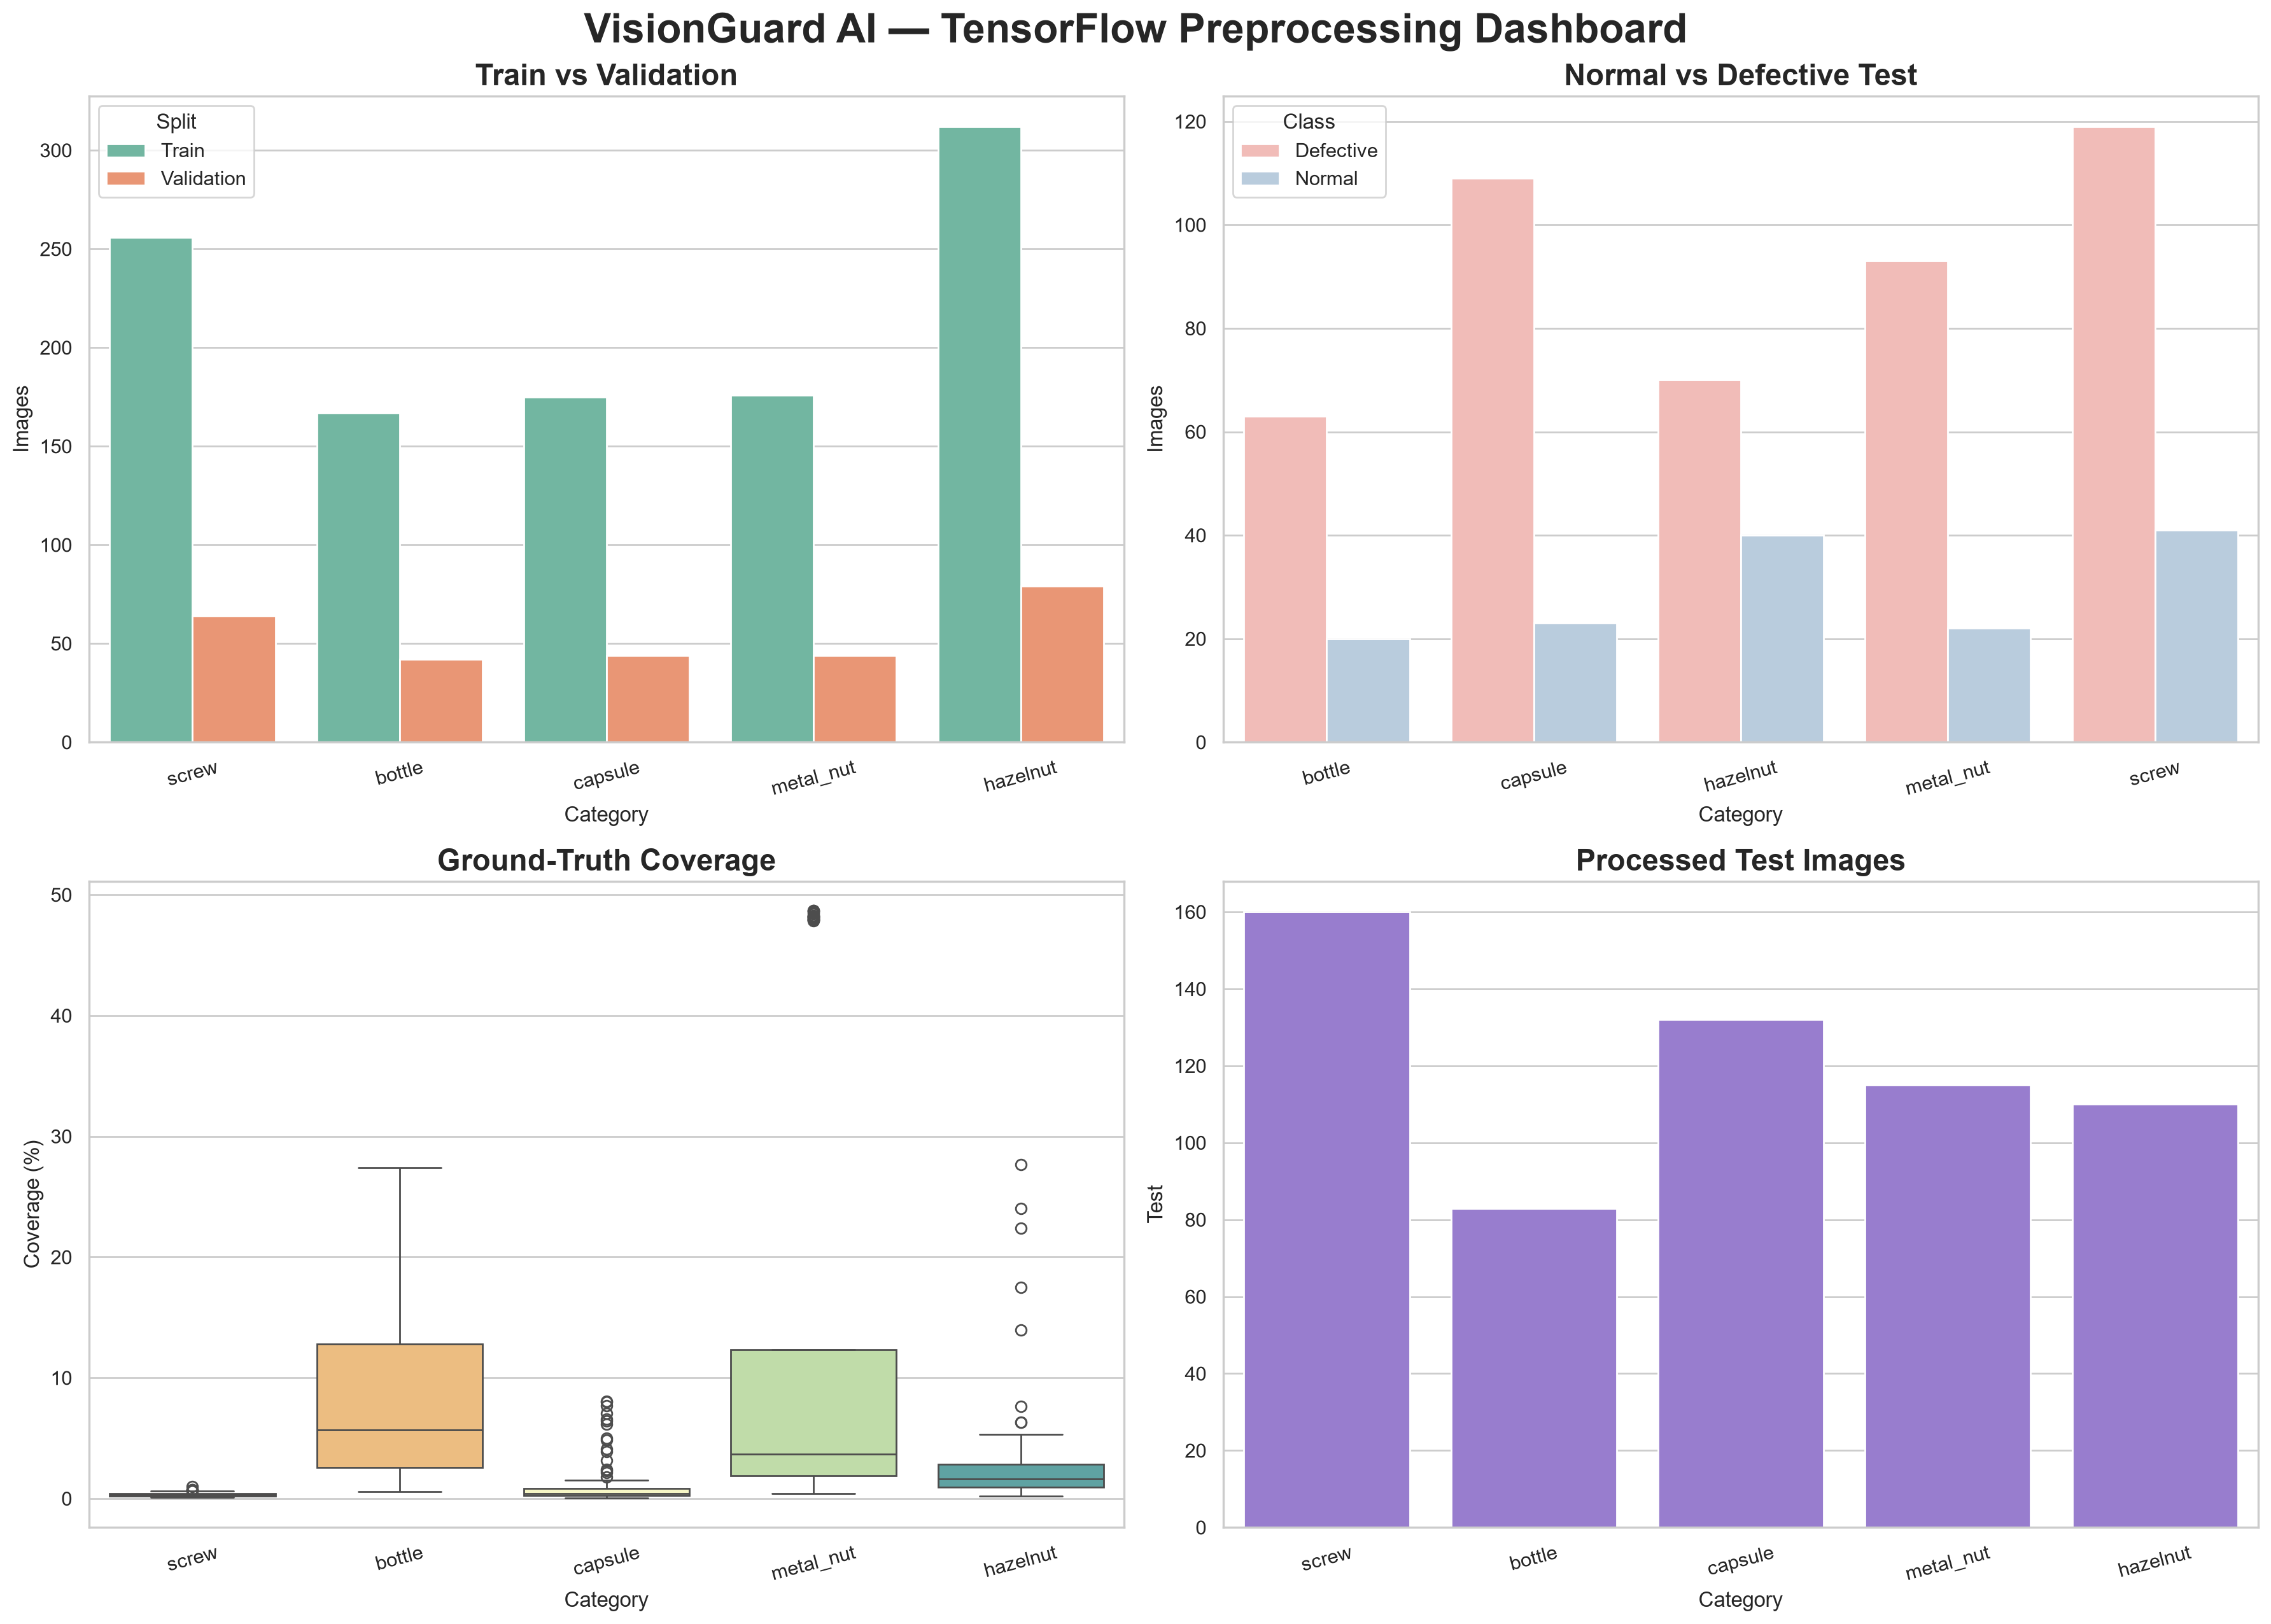

In [34]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 13)
)

sns.barplot(
    data=split_summary.melt(
        id_vars="Category",
        var_name="Split",
        value_name="Images"
    ),
    x="Category",
    y="Images",
    hue="Split",
    palette="Set2",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Train vs Validation",
    fontweight="bold"
)

axes[0, 0].tick_params(
    axis="x",
    rotation=15
)

sns.barplot(
    data=test_balance,
    x="Category",
    y="Images",
    hue="Class",
    palette="Pastel1",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Normal vs Defective Test",
    fontweight="bold"
)

axes[0, 1].tick_params(
    axis="x",
    rotation=15
)

sns.boxplot(
    data=mask_df,
    x="Category",
    y="Coverage (%)",
    palette="Spectral",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Ground-Truth Coverage",
    fontweight="bold"
)

axes[1, 0].tick_params(
    axis="x",
    rotation=15
)

sns.barplot(
    data=processed_stats_df,
    x="Category",
    y="Test",
    color="mediumpurple",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Processed Test Images",
    fontweight="bold"
)

axes[1, 1].tick_params(
    axis="x",
    rotation=15
)

plt.suptitle(
    "VisionGuard AI — TensorFlow Preprocessing Dashboard",
    fontsize=23,
    fontweight="bold"
)

plt.tight_layout()

save_static_figure(
    "tensorflow_preprocessing_dashboard.png"
)

show_saved_figure(
    "tensorflow_preprocessing_dashboard.png"
)

plt.close()


# Complete

The selected MVTec AD data has been prepared for TensorFlow/Keras model development.


In [35]:
DATASET_ROOT = str(RAW_ROOT)
CATEGORIES = [
    "screw",
    "bottle",
    "capsule",
    "metal_nut",
    "hazelnut"
]

print("VisionGuard AI TensorFlow preprocessing completed successfully.")
print(f"Categories processed: {len(CATEGORIES)}")
print(f"Training samples: {len(train_split_df):,}")
print(f"Validation samples: {len(validation_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Ground-truth masks: {len(mask_export_records):,}")
print(f"Target resolution: {IMAGE_WIDTH} × {IMAGE_HEIGHT}")
print("TensorFlow / Keras pipeline: ready")
print("Data augmentation: enabled")
print("Mask resizing: nearest neighbor")
print("Validation checks: passed" if counts_ok else "Validation checks: review")


VisionGuard AI TensorFlow preprocessing completed successfully.
Categories processed: 5
Training samples: 1,086
Validation samples: 273
Test samples: 600
Ground-truth masks: 454
Target resolution: 256 × 256
TensorFlow / Keras pipeline: ready
Data augmentation: enabled
Mask resizing: nearest neighbor
Validation checks: passed
